# Discrete Generation
### From categorical choices to topology-only graphs and general graph generation

**Prerequisites:** VAE, GAN, diffusion basics from previous lectures

This notebook starts with a deliberately simple setting: **topology-only graph generation** with a fixed node order and a fixed number of nodes. This lets us see how VAE, GAN, and diffusion change when the output is discrete.

After those models work, we step back and address the three major graph-generation challenges that the simple setup avoided:

- **Size of the graph:** real graphs may have different numbers of nodes.
- **Feature and topology:** real graphs have node features and edge features, not only binary adjacency.
- **Permutation invariance:** relabeling nodes should not change the graph identity.

| Part | Topic | What changes from continuous generation? |
|------|-------|-------------------------------------------|
| 1 | Why discrete generation is different | We learn distributions over choices, not direct real-valued outputs. |
| 2 | Logits, probabilities, and samples | Neural nets output logits; softmax/sigmoid turn them into probabilities. |
| 3 | Topology-only graph representation | Graph topology becomes a vector of binary edge variables. |
| 4 | GraphVAE and conditional GraphVAE | Decode latent variables into edge probabilities. |
| 5 | GraphGAN and conditional GraphGAN | Train on relaxed edge probabilities, then discretize. |
| 6 | Discrete graph diffusion and conditional diffusion | Corrupt edges discretely, then learn reverse denoising. |
| 7 | What the simple graph models still miss | Identify size, attributes, and permutation invariance as modeling requirements. |
| 8 | Variable-size graphs | Use node-existence variables, padding, masks, or STOP decisions. |
| 9 | Features plus topology | Decode node categories and edge categories jointly with masked losses. |
| 10 | Permutation invariance | Use canonicalization, GNN encoders, invariant pooling, or matching losses. |

**Main theme:** a discrete generator should produce probability distributions over valid next choices: token, edge, node label, atom type, bond type, or graph-construction action.


---
## Part 1 — Why discrete generation is different

Previous lectures mostly worked with images or points:

$$x \in \mathbb{R}^{784}, \qquad x_i \in [0,1].$$

A decoder can output a real-valued vector $\hat{x}$ and we can compare it with MSE or BCE. This is natural for images because pixels live in a continuous or nearly continuous space.

Discrete objects are different:

| Data type | Object | Typical variables |
|---|---|---|
| Image | pixel array | continuous / Bernoulli-ish pixels |
| Point cloud | coordinates | real-valued points |
| Text | sequence | categorical tokens |
| Molecule | graph | atom categories + bond categories |
| Social network | graph | binary edges + node attributes |

For language, the model should not output the word vector directly and hope it lands exactly on the word "cat". It should output:

$$p_\theta(x_t = \text{cat} \mid x_{<t}).$$

For graphs, the model should not output a vague real-valued graph and call it done. It should output probabilities such as:

$$p_\theta(A_{ij}=1 \mid z), \qquad p_\theta(\text{node}_i = \text{carbon} \mid z), \qquad p_\theta(\text{bond}_{ij}=\text{double} \mid z).$$

The key move is:

$$\textbf{continuous neural network output} \rightarrow \textbf{probability distribution} \rightarrow \textbf{discrete sample}.$$


---
## Part 2 — Continuous logits become discrete samples

A neural network still computes continuous numbers. For a categorical variable, those numbers are called **logits**:

$$\ell = (\ell_1,\ldots,\ell_K) \in \mathbb{R}^K.$$

The softmax maps logits to probabilities:

$$p_k = \frac{\exp(\ell_k)}{\sum_j \exp(\ell_j)}.$$

Then we sample:

$$x \sim \mathrm{Categorical}(p_1,\ldots,p_K).$$

This is the same pattern behind language models: the transformer produces logits over the vocabulary, softmax turns them into a distribution, and decoding samples or chooses tokens.


In [1]:

import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

FIG_DPI = 130
PALETTE = {
    "blue": "#2563eb",
    "cyan": "#0891b2",
    "green": "#16a34a",
    "orange": "#f97316",
    "red": "#dc2626",
    "purple": "#7c3aed",
    "gray": "#64748b",
    "dark": "#0f172a",
}

plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.labelcolor": PALETTE["dark"],
    "xtick.color": PALETTE["dark"],
    "ytick.color": PALETTE["dark"],
    "font.size": 10,
    "legend.frameon": False,
})


def finish_axis(ax, title=None, xlabel=None, ylabel=None, grid=True):
    if title:
        ax.set_title(title, pad=8)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if grid:
        ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
    return ax


device: cuda


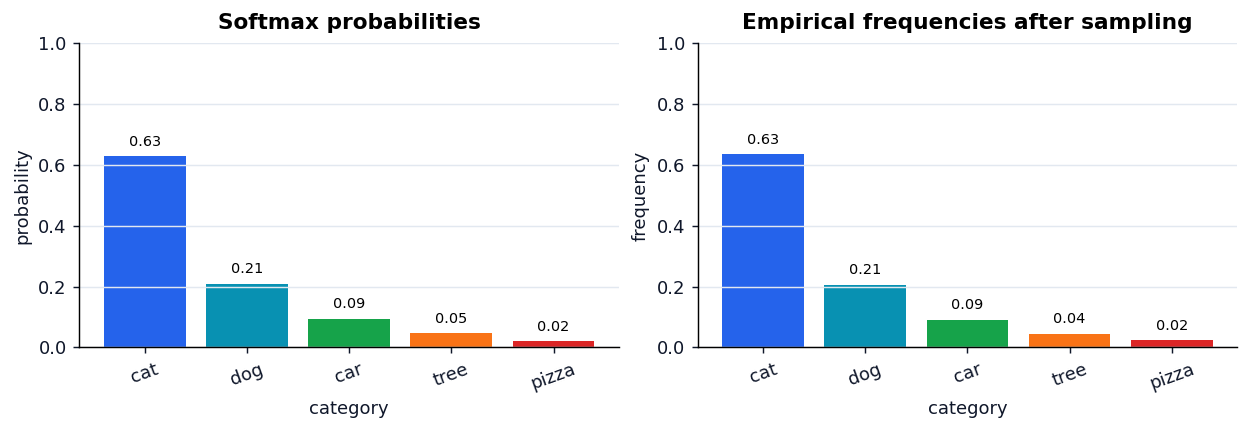

In [2]:

classes = np.array(["cat", "dog", "car", "tree", "pizza"])
logits = torch.tensor([2.2, 1.1, 0.3, -0.4, -1.2])
probs = F.softmax(logits, dim=0)
samples = torch.multinomial(probs, num_samples=3000, replacement=True)
counts = torch.bincount(samples, minlength=len(classes)).float() / samples.numel()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), constrained_layout=True)
bar_colors = [PALETTE["blue"], PALETTE["cyan"], PALETTE["green"], PALETTE["orange"], PALETTE["red"]]

axes[0].bar(classes, probs.numpy(), color=bar_colors)
finish_axis(axes[0], "Softmax probabilities", "category", "probability")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
for idx, value in enumerate(probs.numpy()):
    axes[0].text(idx, value + 0.025, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

axes[1].bar(classes, counts.numpy(), color=bar_colors)
finish_axis(axes[1], "Empirical frequencies after sampling", "category", "frequency")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)
for idx, value in enumerate(counts.numpy()):
    axes[1].text(idx, value + 0.025, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

plt.show()



---
## Part 3 — Topology-only graphs as discrete random variables

We first remove node and edge attributes and study only graph topology. A simple undirected graph with $n$ nodes can be represented by an adjacency matrix:

$$A \in \{0,1\}^{n \times n}, \qquad A_{ij}=1 \text{ means an edge exists between nodes } i,j.$$

For an undirected graph without self-loops, we only need the upper triangular entries:

$$x = (A_{12}, A_{13}, \ldots, A_{n-1,n}) \in \{0,1\}^{n(n-1)/2}.$$

So a topology-only graph generator learns many coupled Bernoulli variables:

$$p_\theta(A \mid z) = \prod_{i<j} \mathrm{Bernoulli}(A_{ij}; \pi_{ij}(z)).$$

This independent-edge decoder is not the full story, but it is the cleanest bridge from VAE/GAN/diffusion into graph generation. After this topology-only pass, we will add atom and bond categories for molecule-like attributed graphs.

Important graph-specific complications:

- **Validity:** generated graphs may need chemical valence, connectivity, grammar, or domain constraints.
- **Permutation invariance:** relabeling nodes should not change the graph identity.
- **Discrete sampling:** sampling edges breaks ordinary backpropagation, so training often uses probabilities, relaxations, or policy-gradient style objectives.


In [3]:

N_NODES = 6
UPPER_IDX = np.triu_indices(N_NODES, k=1)
EDGE_PAIRS = list(zip(*UPPER_IDX))
EDGE_LABELS = [f"{i}-{j}" for i, j in EDGE_PAIRS]
N_EDGES = len(EDGE_PAIRS)

angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, N_NODES, endpoint=False)
NODE_POS = np.column_stack([np.cos(angles), np.sin(angles)])


def adj_to_vec(A):
    return np.asarray(A, dtype=np.float32)[UPPER_IDX]


def vec_to_adj(vec, n_nodes=N_NODES):
    A = np.zeros((n_nodes, n_nodes), dtype=np.float32)
    idx = np.triu_indices(n_nodes, k=1)
    A[idx] = np.asarray(vec, dtype=np.float32)
    A = A + A.T
    return A


def base_graph(kind):
    A = np.zeros((N_NODES, N_NODES), dtype=np.float32)
    if kind == "cycle":
        edges = [(i, (i + 1) % N_NODES) for i in range(N_NODES)]
    elif kind == "star":
        edges = [(0, i) for i in range(1, N_NODES)]
    elif kind == "path":
        edges = [(i, i + 1) for i in range(N_NODES - 1)]
    elif kind == "two_triangles":
        edges = [(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3)]
    else:
        raise ValueError(f"unknown graph kind: {kind}")
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1
    return A


def noisy_graph(kind, flip_p=0.04):
    A = base_graph(kind).copy()
    flips = np.random.rand(N_EDGES) < flip_p
    vec = adj_to_vec(A)
    vec[flips] = 1 - vec[flips]
    return vec_to_adj(vec)


def plot_graph_grid(graphs, titles=None, cols=4, figsize=None, node_size=0.11, title=None, cmap="viridis"):
    graphs = [np.asarray(graph, dtype=np.float32) for graph in graphs]
    n_graphs = len(graphs)
    rows = math.ceil(n_graphs / cols)
    if figsize is None:
        figsize = (2.35 * cols, 2.15 * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False, constrained_layout=True)

    for idx, ax in enumerate(axes.flat):
        ax.set_axis_off()
        if idx >= n_graphs:
            continue

        A = np.clip(graphs[idx], 0, 1)
        upper_values = A[UPPER_IDX]
        is_soft = np.any((upper_values > 0) & (upper_values < 1))
        segments, widths = [], []
        # Thickness-only rendering: edge color is constant; predicted strength is shown only via linewidth.
        edge_color = (0.18, 0.18, 0.18, 0.88)

        for i, j in EDGE_PAIRS:
            weight = float(A[i, j])

            # For hard (binary) graphs we draw only present edges.
            if not is_soft:
                if weight < 0.5:
                    continue
                segments.append([NODE_POS[i], NODE_POS[j]])
                widths.append(2.2)
                continue

            # For soft graphs we draw all edges, using *only thickness* to indicate strength.
            # Keep low-probability edges visible, but still make high-probability edges stand out.
            segments.append([NODE_POS[i], NODE_POS[j]])
            widths.append(0.55 + 2.05 * np.sqrt(weight))

        if segments:
            ax.add_collection(LineCollection(segments, colors=edge_color, linewidths=widths, zorder=1))

        ax.scatter(
            NODE_POS[:, 0], NODE_POS[:, 1],
            s=node_size * 950,
            c="white",
            edgecolors=PALETTE["dark"],
            linewidths=1.2,
            zorder=2,
        )
        for node_idx, (x_pos, y_pos) in enumerate(NODE_POS):
            ax.text(x_pos, y_pos, str(node_idx), ha="center", va="center", fontsize=7.5, zorder=3)

        if titles is not None:
            ax.set_title(titles[idx], fontsize=9.5, pad=3)
        ax.set_xlim(-1.25, 1.25)
        ax.set_ylim(-1.25, 1.25)
        ax.set_aspect("equal")

    if title:
        fig.suptitle(title, fontsize=12, fontweight="semibold")
    plt.show()
    return fig, axes


graph vectors: (1000, 15)
each vector contains the 15 upper-triangular edge variables


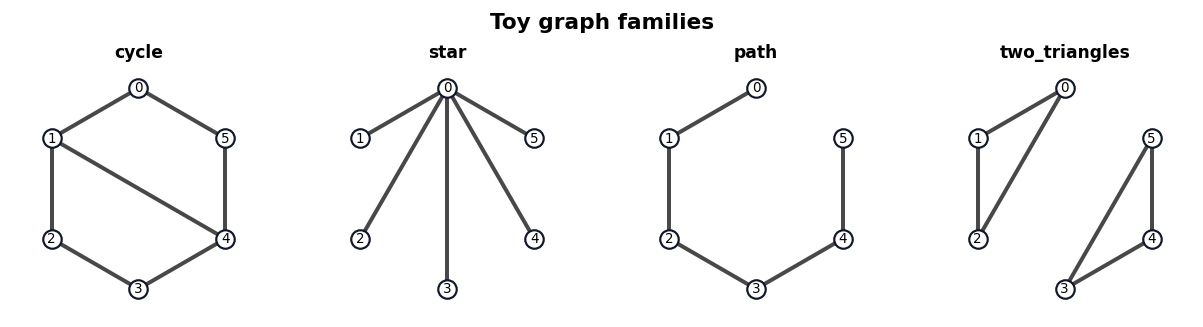

(<Figure size 1235x312 with 4 Axes>,
 array([[<Axes: title={'center': 'cycle'}>,
         <Axes: title={'center': 'star'}>,
         <Axes: title={'center': 'path'}>,
         <Axes: title={'center': 'two_triangles'}>]], dtype=object))

In [4]:

# Build a small toy graph dataset.
kinds = ["cycle", "star", "path", "two_triangles"]
X_graph, y_graph = [], []
for label, kind in enumerate(kinds):
    for _ in range(250):
        A = noisy_graph(kind)
        X_graph.append(adj_to_vec(A))
        y_graph.append(label)

X_graph = np.stack(X_graph).astype(np.float32)
y_graph = np.array(y_graph)
perm = np.random.permutation(len(X_graph))
X_graph, y_graph = X_graph[perm], y_graph[perm]
X_tensor = torch.tensor(X_graph, dtype=torch.float32)
y_tensor = torch.tensor(y_graph, dtype=torch.long)

print("graph vectors:", X_graph.shape)
print("each vector contains the", N_EDGES, "upper-triangular edge variables")

example_graphs = [vec_to_adj(X_graph[np.where(y_graph == k)[0][0]]) for k in range(len(kinds))]
plot_graph_grid(example_graphs, titles=kinds, cols=4, figsize=(9.5, 2.4), title="Toy graph families")



---
## Part 4 — Topology-only GraphVAE

The VAE structure is still familiar:

$$x \xrightarrow{\text{encoder}} q_\phi(z \mid x) \xrightarrow{\text{sample}} z \xrightarrow{\text{decoder}} p_\theta(x \mid z).$$

For images, $p_\theta(x \mid z)$ might output pixel means. For topology-only graphs, the decoder outputs edge probabilities:

$$p_\theta(A \mid z) = \prod_{i<j}\mathrm{Bernoulli}(A_{ij}; \pi_{ij}(z)).$$

The reconstruction term becomes binary cross-entropy over edges:

$$\mathcal{L}_{\text{edge}} = -\sum_{i<j}\left[A_{ij}\log\pi_{ij} + (1-A_{ij})\log(1-\pi_{ij})\right].$$

To make the toy graph families easier to visualize in latent space, this version also adds a small supervised prototype loss on the encoder mean $\mu_\phi(A)$:

$$s_y(A) = -\|\mu_\phi(A)-c_y\|_2^2, \qquad \mathcal{L}_{\text{sup}} = \mathrm{CE}(s(A), y).$$

The training objective is:

$$\mathcal{L} = \mathcal{L}_{\text{edge}} + \beta\,D_{\mathrm{KL}}\left(q_\phi(z\mid A)\,\|\,p(z)\right) + \gamma\,\mathcal{L}_{\text{sup}}.$$

This is still a topology-only model: the output is only the edge vector. Later, the attributed model will add separate categorical heads for atoms and bonds.


In [5]:

class GraphVAE(nn.Module):
    def __init__(self, n_edges=N_EDGES, latent_dim=8, hidden=64, n_classes=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_edges, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu = nn.Linear(hidden, latent_dim)
        self.logvar = nn.Linear(hidden, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_edges),
        )
        self.class_centers = nn.Parameter(0.1 * torch.randn(n_classes, latent_dim))

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_logits(self, z):
        return self.decoder(z)

    def latent_class_logits(self, mu):
        # Higher score means closer to a learned class prototype in latent space.
        return -torch.cdist(mu, self.class_centers).pow(2)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_logits(z)
        return logits, mu, logvar


def vae_loss(logits, x, mu, logvar, class_logits=None, labels=None, beta=0.05, gamma=1.0):
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    supervised = torch.zeros((), device=x.device)
    if class_logits is not None and labels is not None:
        supervised = F.cross_entropy(class_logits, labels)
    total = recon + beta * kl + gamma * supervised
    return total, recon.detach(), kl.detach(), supervised.detach()


epoch  100 | total 1.658 | edge BCE 1.122 | KL 8.749 | supervised CE 0.099 | latent acc 97.9%
epoch  200 | total 0.919 | edge BCE 0.381 | KL 9.033 | supervised CE 0.086 | latent acc 98.2%
epoch  300 | total 0.680 | edge BCE 0.166 | KL 8.756 | supervised CE 0.076 | latent acc 98.2%
epoch  400 | total 0.563 | edge BCE 0.094 | KL 7.954 | supervised CE 0.072 | latent acc 98.1%
epoch  500 | total 0.544 | edge BCE 0.069 | KL 8.132 | supervised CE 0.069 | latent acc 98.2%
epoch  600 | total 0.527 | edge BCE 0.091 | KL 7.346 | supervised CE 0.068 | latent acc 98.3%
epoch  700 | total 0.492 | edge BCE 0.060 | KL 7.297 | supervised CE 0.068 | latent acc 98.1%
epoch  800 | total 0.471 | edge BCE 0.046 | KL 7.157 | supervised CE 0.067 | latent acc 98.3%
epoch  900 | total 0.469 | edge BCE 0.045 | KL 7.197 | supervised CE 0.065 | latent acc 98.3%
epoch 1000 | total 0.465 | edge BCE 0.029 | KL 7.312 | supervised CE 0.070 | latent acc 98.2%


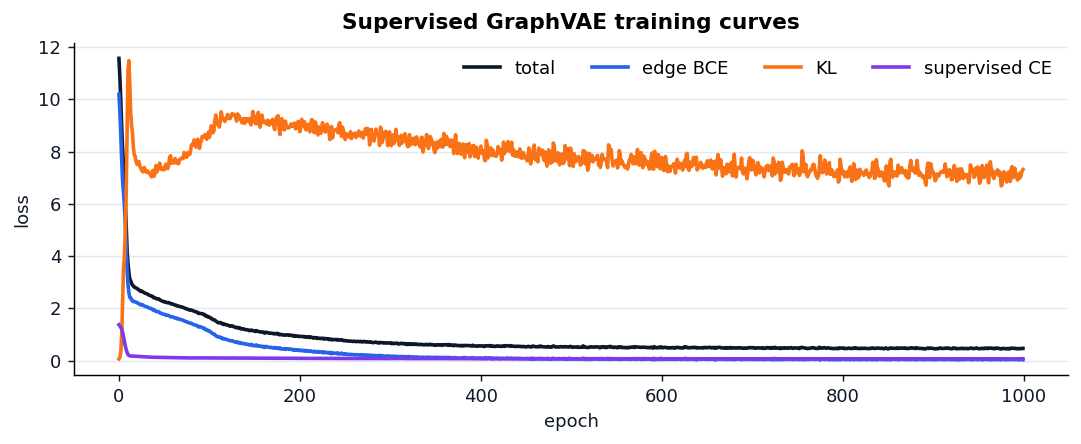

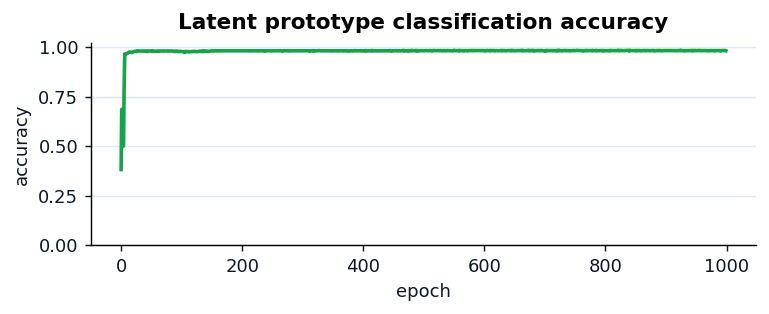

In [6]:

vae_latent_dim = 8
supervised_weight = 1.0
vae = GraphVAE(latent_dim=vae_latent_dim, n_classes=len(kinds)).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
vae_dl = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=128, shuffle=True)
vae_history = []

for epoch in range(1, 1001):
    total_epoch = recon_epoch = kl_epoch = sup_epoch = 0.0
    correct = 0
    for x_batch, y_batch in vae_dl:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        logits, mu, logvar = vae(x_batch)
        class_logits = vae.latent_class_logits(mu)
        loss, recon, kl, supervised = vae_loss(
            logits,
            x_batch,
            mu,
            logvar,
            class_logits=class_logits,
            labels=y_batch,
            gamma=supervised_weight,
        )
        opt_vae.zero_grad()
        loss.backward()
        opt_vae.step()

        batch_size = x_batch.size(0)
        total_epoch += loss.item() * batch_size
        recon_epoch += recon.item() * batch_size
        kl_epoch += kl.item() * batch_size
        sup_epoch += supervised.item() * batch_size
        correct += (class_logits.argmax(dim=1) == y_batch).sum().item()

    vae_history.append((
        total_epoch / len(vae_dl.dataset),
        recon_epoch / len(vae_dl.dataset),
        kl_epoch / len(vae_dl.dataset),
        sup_epoch / len(vae_dl.dataset),
        correct / len(vae_dl.dataset),
    ))
    if epoch % 100 == 0:
        total, recon, kl, sup, acc = vae_history[-1]
        print(
            f"epoch {epoch:4d} | total {total:.3f} | edge BCE {recon:.3f} | "
            f"KL {kl:.3f} | supervised CE {sup:.3f} | latent acc {acc:.1%}"
        )

history = np.array(vae_history)
fig, ax = plt.subplots(figsize=(8.2, 3.3), constrained_layout=True)
ax.plot(history[:, 0], label="total", color=PALETTE["dark"], linewidth=2)
ax.plot(history[:, 1], label="edge BCE", color=PALETTE["blue"], linewidth=2)
ax.plot(history[:, 2], label="KL", color=PALETTE["orange"], linewidth=2)
ax.plot(history[:, 3], label="supervised CE", color=PALETTE["purple"], linewidth=2)
finish_axis(ax, "Supervised GraphVAE training curves", "epoch", "loss")
ax.legend(ncol=4, loc="upper right")
plt.show()

fig, ax = plt.subplots(figsize=(5.8, 2.3), constrained_layout=True)
ax.plot(history[:, 4], color=PALETTE["green"], linewidth=2)
ax.set_ylim(0, 1.02)
finish_axis(ax, "Latent prototype classification accuracy", "epoch", "accuracy")
plt.show()


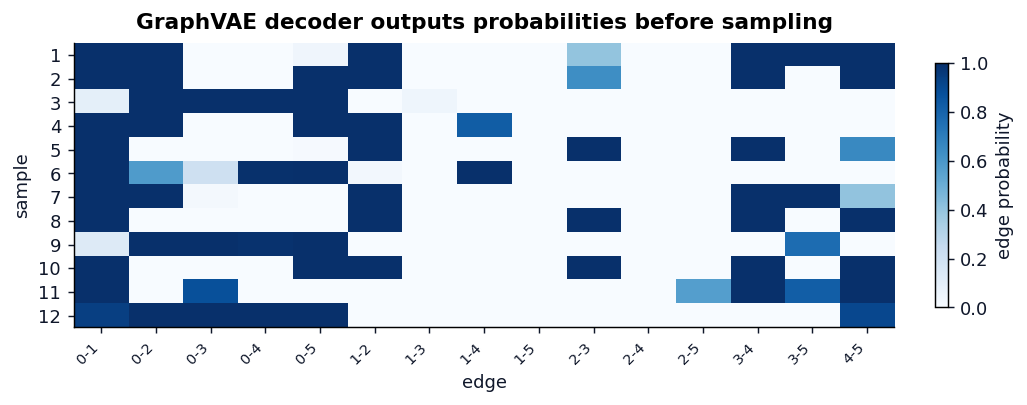

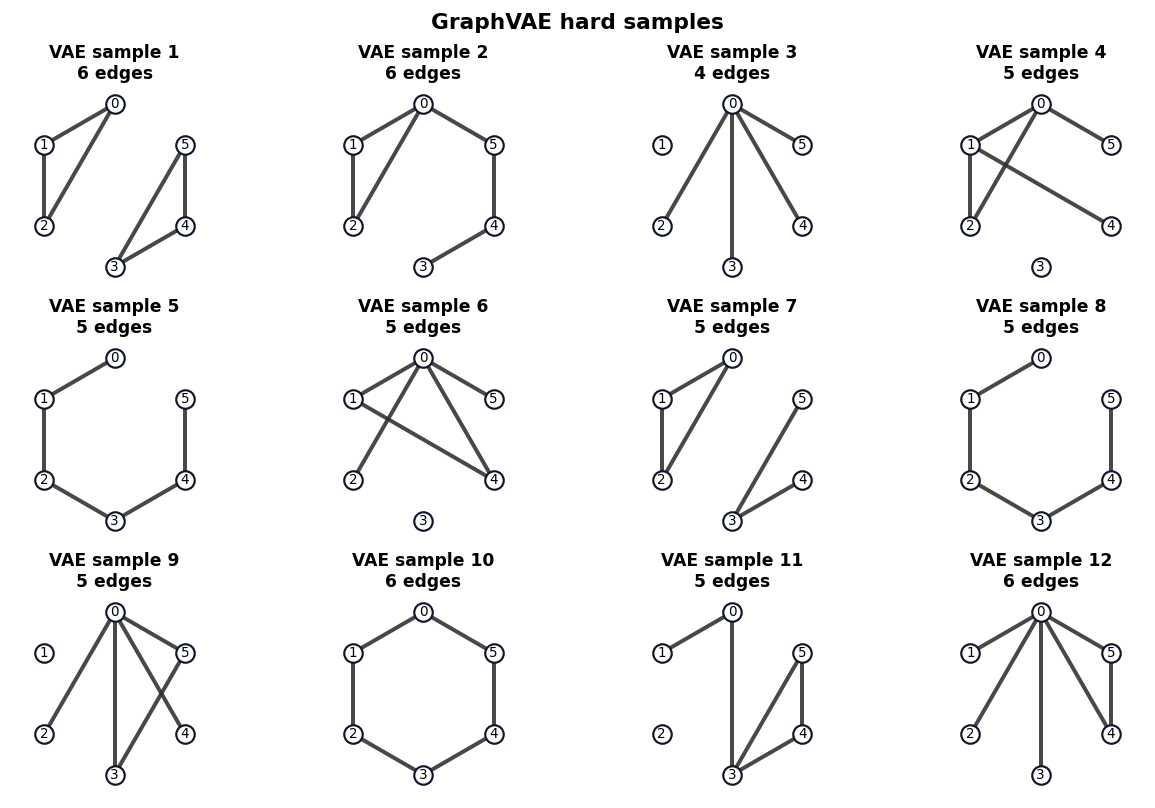

(<Figure size 1235x793 with 12 Axes>,
 array([[<Axes: title={'center': 'VAE sample 1\n6 edges'}>,
         <Axes: title={'center': 'VAE sample 2\n6 edges'}>,
         <Axes: title={'center': 'VAE sample 3\n4 edges'}>,
         <Axes: title={'center': 'VAE sample 4\n5 edges'}>],
        [<Axes: title={'center': 'VAE sample 5\n5 edges'}>,
         <Axes: title={'center': 'VAE sample 6\n5 edges'}>,
         <Axes: title={'center': 'VAE sample 7\n5 edges'}>,
         <Axes: title={'center': 'VAE sample 8\n5 edges'}>],
        [<Axes: title={'center': 'VAE sample 9\n5 edges'}>,
         <Axes: title={'center': 'VAE sample 10\n6 edges'}>,
         <Axes: title={'center': 'VAE sample 11\n5 edges'}>,
         <Axes: title={'center': 'VAE sample 12\n6 edges'}>]], dtype=object))

In [7]:

vae.eval()
with torch.no_grad():
    z = torch.randn(12, vae_latent_dim, device=device)
    edge_probs = torch.sigmoid(vae.decode_logits(z)).cpu().numpy()

rng = np.random.default_rng(42)
edge_samples = (rng.random(edge_probs.shape) < edge_probs).astype(np.float32)

fig, ax = plt.subplots(figsize=(7.8, 3.0), constrained_layout=True)
im = ax.imshow(edge_probs, aspect="auto", cmap="Blues", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="edge probability", shrink=0.86)
ax.set_xticks(range(N_EDGES))
ax.set_xticklabels(EDGE_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(edge_probs.shape[0]))
ax.set_yticklabels([str(i + 1) for i in range(edge_probs.shape[0])])
finish_axis(ax, "GraphVAE decoder outputs probabilities before sampling", "edge", "sample", grid=False)
plt.show()

vae_graphs = [vec_to_adj(edge_samples[i]) for i in range(edge_samples.shape[0])]
vae_titles = [f"VAE sample {i + 1}\n{int(edge_samples[i].sum())} edges" for i in range(edge_samples.shape[0])]
plot_graph_grid(vae_graphs, titles=vae_titles, cols=4, figsize=(9.5, 6.1), title="GraphVAE hard samples")


RECONSTRUCTION TEST: Real → Encoder → Decoder


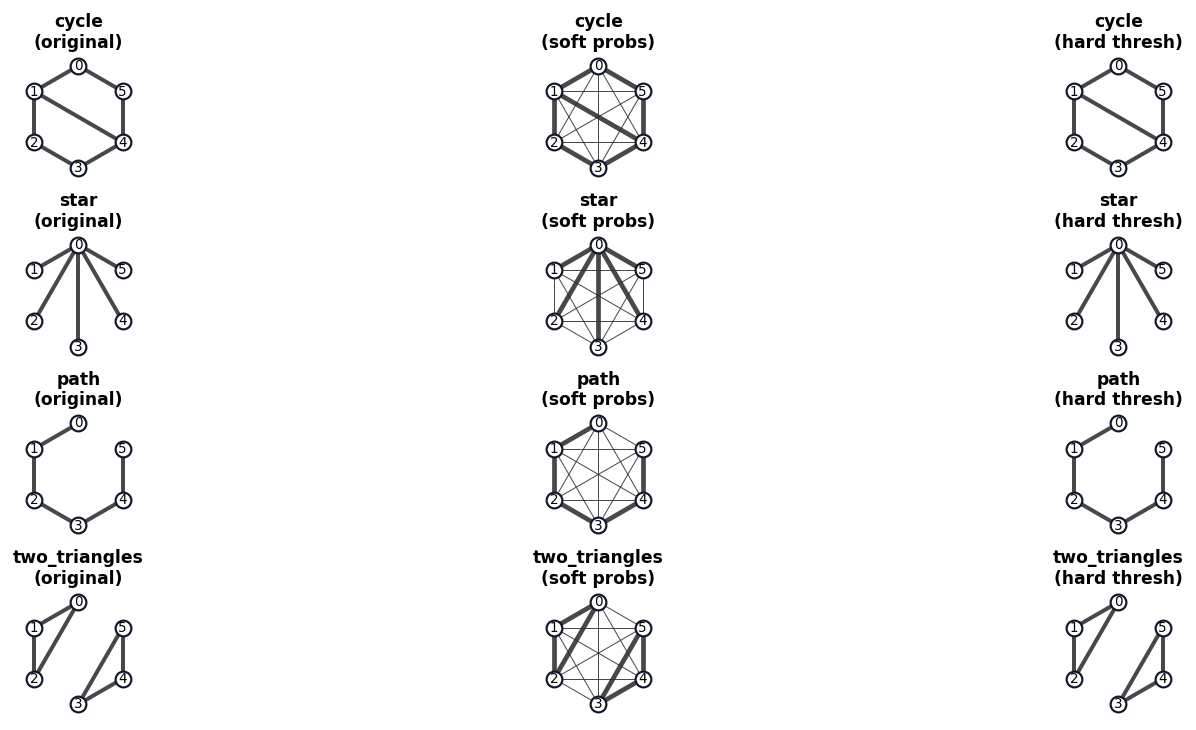


Reconstruction accuracy per graph type:
  cycle               : 100.0%
  star                : 100.0%
  path                : 100.0%
  two_triangles       : 100.0%
  Average: 100.0%


In [8]:
# === Part 4 Validation: Verify the GraphVAE is learning ===

# 1. Reconstruction: encode real graphs and decode them
print("="*50)
print("RECONSTRUCTION TEST: Real → Encoder → Decoder")
print("="*50)

vae.eval()
test_indices = [np.where(y_graph == k)[0][0] for k in range(len(kinds))]
test_graphs = [X_graph[i] for i in test_indices]

with torch.no_grad():
    X_test_tensor = torch.tensor(np.stack(test_graphs), dtype=torch.float32).to(device)
    logits_recon, mu_recon, _ = vae(X_test_tensor)
    recon_probs = torch.sigmoid(logits_recon).cpu().numpy()
    recon_hard = (recon_probs >= 0.5).astype(np.float32)

# Visualize: original vs reconstructed edge probabilities vs hard threshold
viz_recon = []
viz_titles = []
for k in range(len(kinds)):
    viz_recon.append(vec_to_adj(test_graphs[k]))
    viz_titles.append(f"{kinds[k]}\n(original)")
    viz_recon.append(vec_to_adj(recon_probs[k]))
    viz_titles.append(f"{kinds[k]}\n(soft probs)")
    viz_recon.append(vec_to_adj(recon_hard[k]))
    viz_titles.append(f"{kinds[k]}\n(hard thresh)")

plot_graph_grid(viz_recon, titles=viz_titles, cols=3, node_size=0.08, figsize=(12, 5.5))

# Reconstruction accuracy
recon_acc = (recon_hard == test_graphs).mean(axis=1)
print(f"\nReconstruction accuracy per graph type:")
for k, kind in enumerate(kinds):
    print(f"  {kind:20s}: {recon_acc[k]:.1%}")
print(f"  Average: {recon_acc.mean():.1%}")


Latent prototype classification accuracy: 98.3%


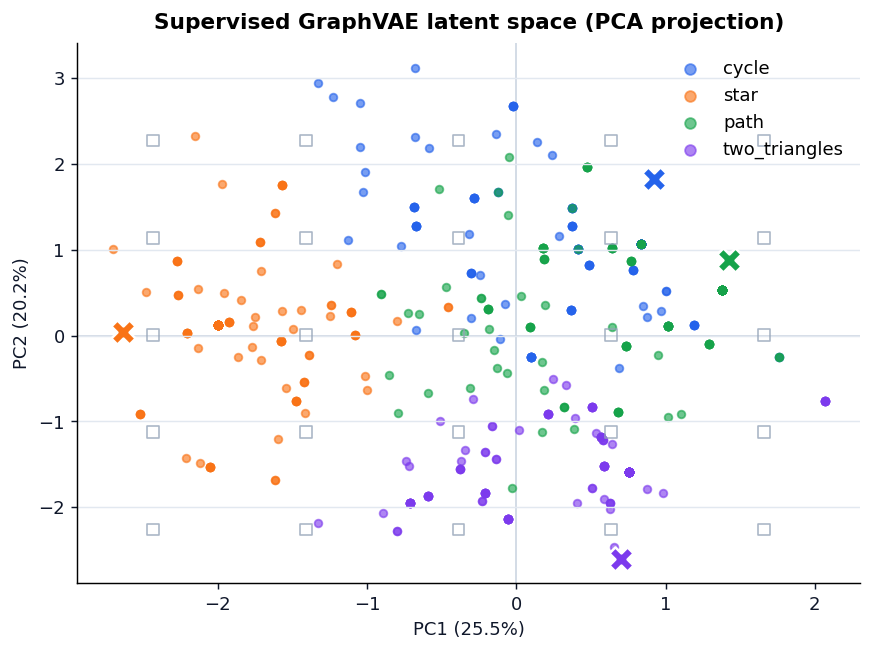

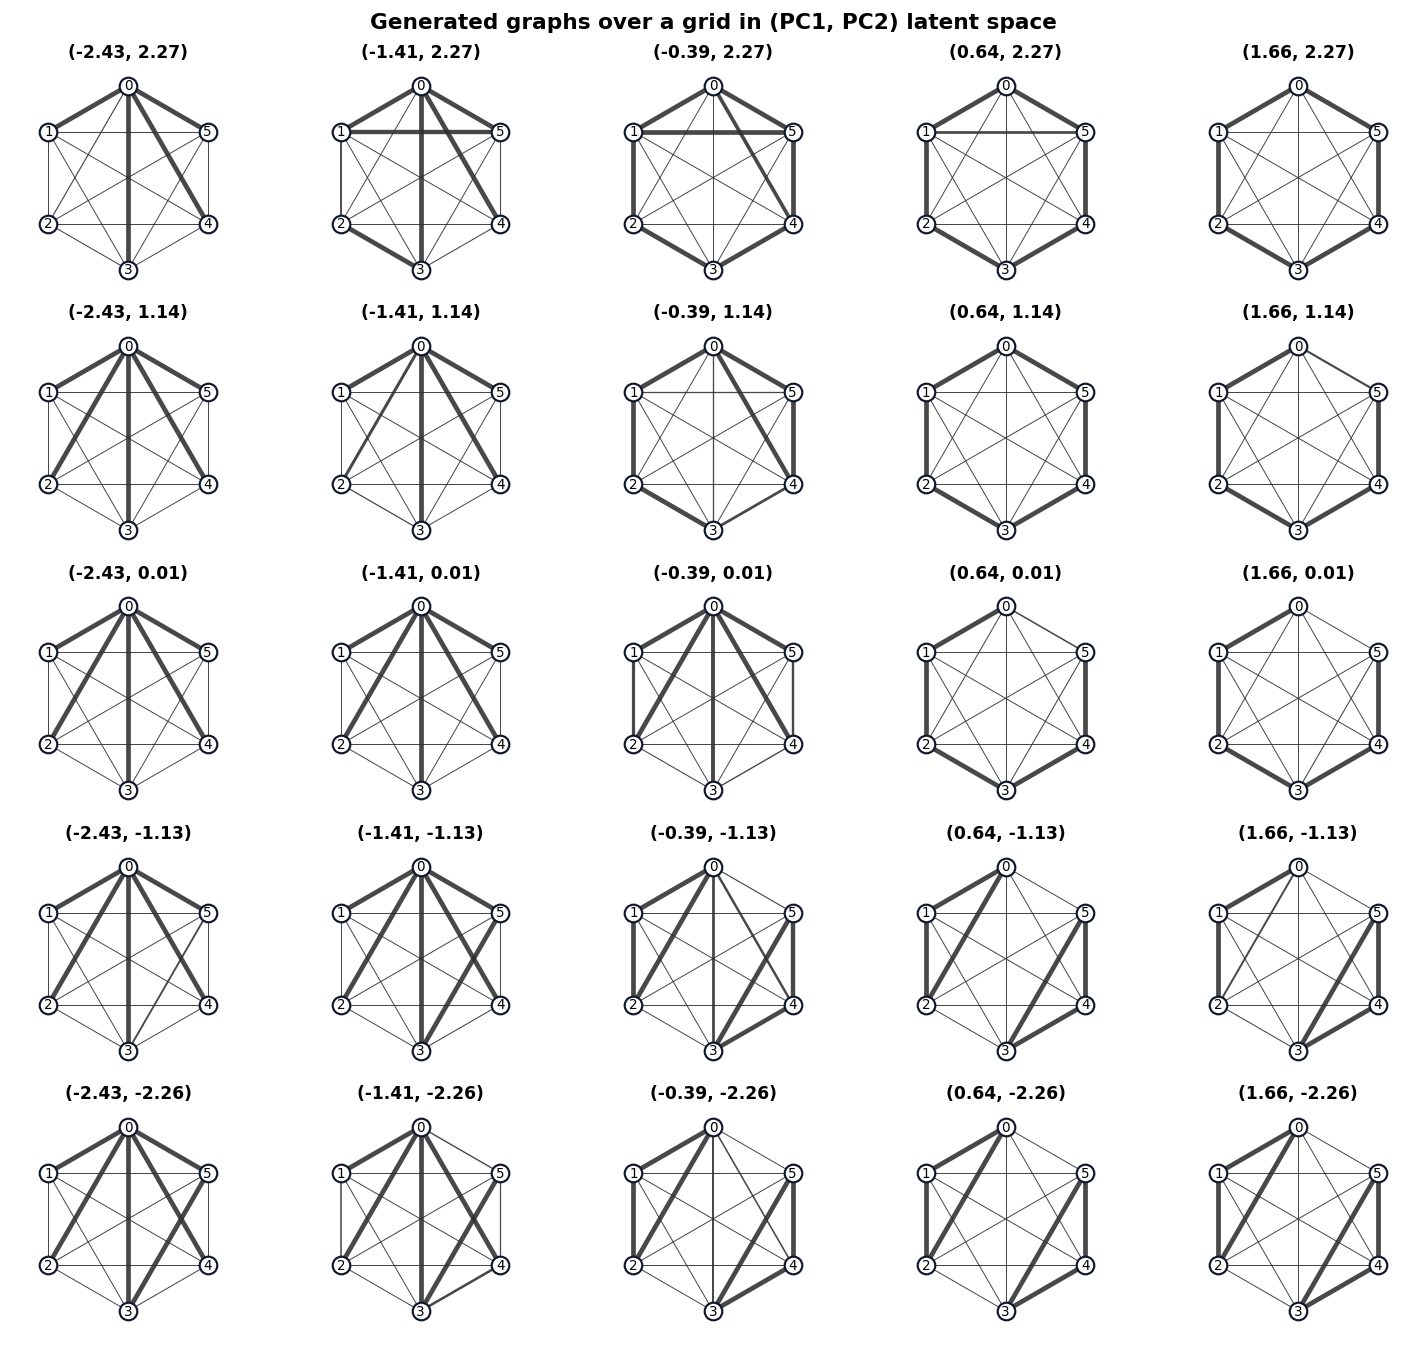

(<Figure size 1462.5x1332.5 with 25 Axes>,
 array([[<Axes: title={'center': '(-2.43, 2.27)'}>,
         <Axes: title={'center': '(-1.41, 2.27)'}>,
         <Axes: title={'center': '(-0.39, 2.27)'}>,
         <Axes: title={'center': '(0.64, 2.27)'}>,
         <Axes: title={'center': '(1.66, 2.27)'}>],
        [<Axes: title={'center': '(-2.43, 1.14)'}>,
         <Axes: title={'center': '(-1.41, 1.14)'}>,
         <Axes: title={'center': '(-0.39, 1.14)'}>,
         <Axes: title={'center': '(0.64, 1.14)'}>,
         <Axes: title={'center': '(1.66, 1.14)'}>],
        [<Axes: title={'center': '(-2.43, 0.01)'}>,
         <Axes: title={'center': '(-1.41, 0.01)'}>,
         <Axes: title={'center': '(-0.39, 0.01)'}>,
         <Axes: title={'center': '(0.64, 0.01)'}>,
         <Axes: title={'center': '(1.66, 0.01)'}>],
        [<Axes: title={'center': '(-2.43, -1.13)'}>,
         <Axes: title={'center': '(-1.41, -1.13)'}>,
         <Axes: title={'center': '(-0.39, -1.13)'}>,
         <Axes: title

In [9]:

# 2. Latent space: encode all graphs and inspect the first two PCA directions.
vae.eval()
with torch.no_grad():
    mu_all, _ = vae.encode(X_tensor.to(device))
    latent_logits = vae.latent_class_logits(mu_all)
    latent_pred = latent_logits.argmax(dim=1).cpu().numpy()
    class_centers = vae.class_centers.cpu().numpy()

latent = mu_all.cpu().numpy()
latent_acc = (latent_pred == y_graph).mean()
print(f"Latent prototype classification accuracy: {latent_acc:.1%}")

latent_mean = latent.mean(axis=0, keepdims=True)
latent_centered = latent - latent_mean
_, singular_values, vh = np.linalg.svd(latent_centered, full_matrices=False)
latent_2d = latent_centered @ vh[:2].T
center_2d = (class_centers - latent_mean) @ vh[:2].T
explained = singular_values**2 / (len(latent_centered) - 1)
explained_ratio = explained / explained.sum()

# Lay down a uniform grid in (PC1, PC2) space and decode each grid point.
# This makes the relationship between location in latent space and generated graph concrete.
grid_n = 5
pc1_lo, pc1_hi = np.percentile(latent_2d[:, 0], [2, 98])
pc2_lo, pc2_hi = np.percentile(latent_2d[:, 1], [2, 98])
pad_x = 0.08 * (pc1_hi - pc1_lo + 1e-8)
pad_y = 0.08 * (pc2_hi - pc2_lo + 1e-8)
pc1_vals = np.linspace(pc1_lo - pad_x, pc1_hi + pad_x, grid_n)
pc2_vals = np.linspace(pc2_lo - pad_y, pc2_hi + pad_y, grid_n)

# Order is row-major with PC2 decreasing so the plot grid reads top-to-bottom.
grid_pc = np.array([(x, y) for y in pc2_vals[::-1] for x in pc1_vals], dtype=np.float32)

fig, ax = plt.subplots(figsize=(6.6, 4.9), constrained_layout=True)
colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["green"], PALETTE["purple"]]
for label, kind in enumerate(kinds):
    mask = y_graph == label
    ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1], s=18, alpha=0.62, label=kind, color=colors[label])
    ax.scatter(
        center_2d[label, 0],
        center_2d[label, 1],
        marker="X",
        s=180,
        color=colors[label],
        edgecolors="white",
        linewidths=1.4,
        zorder=4,
    )

# Overlay grid points (these are the points we will decode and visualize below).
ax.scatter(
    grid_pc[:, 0],
    grid_pc[:, 1],
    s=42,
    marker="s",
    facecolors="none",
    edgecolors="#94a3b8",
    linewidths=0.9,
    alpha=0.8,
    zorder=2,
    label="_nolegend_",
)

finish_axis(
    ax,
    "Supervised GraphVAE latent space (PCA projection)",
    f"PC1 ({explained_ratio[0]:.1%})",
    f"PC2 ({explained_ratio[1]:.1%})",
    grid=True,
)
ax.axhline(0, color="#cbd5e1", linewidth=0.9, zorder=0)
ax.axvline(0, color="#cbd5e1", linewidth=0.9, zorder=0)
ax.legend(markerscale=1.4, loc="best")
plt.show()

# Decode each grid point back into the original latent space and generate a graph.
vae.eval()
grid_graphs, grid_titles = [], []
with torch.no_grad():
    mean_vec = latent_mean.squeeze(0).astype(np.float32)
    pc_basis = vh[:2].astype(np.float32)  # (2, latent_dim)

    for pc1, pc2 in grid_pc:
        z = mean_vec + np.array([pc1, pc2], dtype=np.float32) @ pc_basis
        z_tensor = torch.tensor(z, dtype=torch.float32, device=device).unsqueeze(0)
        logits = vae.decode_logits(z_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        grid_graphs.append(vec_to_adj(probs))
        grid_titles.append(f"({pc1:.2f}, {pc2:.2f})")

plot_graph_grid(
    grid_graphs,
    titles=grid_titles,
    cols=grid_n,
    node_size=0.10,
    figsize=(2.25 * grid_n, 2.05 * grid_n),
    title="Generated graphs over a grid in (PC1, PC2) latent space",
    cmap="plasma",
)



INTERPOLATION: Smooth morphing in latent space


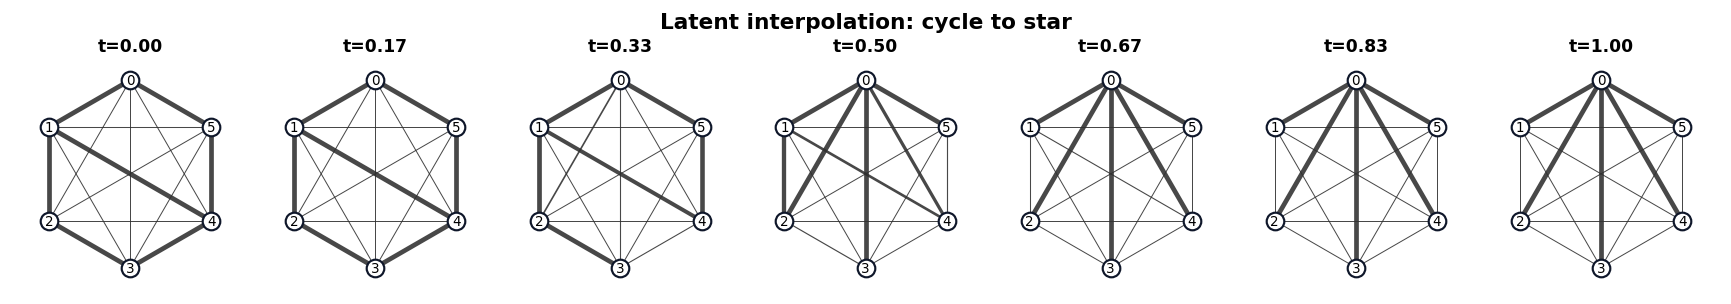


Showing smooth morphing from 'cycle' to 'star' via latent interpolation
This demonstrates that the encoder learns a meaningful continuous latent structure.


In [10]:

# 3. Latent interpolation: smooth transitions between graph types.
print("\n" + "=" * 50)
print("INTERPOLATION: Smooth morphing in latent space")
print("=" * 50)

vae.eval()
idx_cycle = np.where(y_graph == 0)[0][0]
idx_star = np.where(y_graph == 1)[0][0]

with torch.no_grad():
    x_cycle = torch.tensor(X_graph[idx_cycle:idx_cycle + 1], dtype=torch.float32).to(device)
    x_star = torch.tensor(X_graph[idx_star:idx_star + 1], dtype=torch.float32).to(device)

    mu_cycle, _ = vae.encode(x_cycle)
    mu_star, _ = vae.encode(x_star)

    n_steps = 7
    interp_graphs = []
    interp_titles = []

    for step in np.linspace(0, 1, n_steps):
        z_interp = (1 - step) * mu_cycle + step * mu_star
        logits_interp = vae.decode_logits(z_interp)
        probs_interp = torch.sigmoid(logits_interp).cpu().numpy()[0]
        interp_graphs.append(vec_to_adj(probs_interp))
        interp_titles.append(f"t={step:.2f}")

plot_graph_grid(
    interp_graphs,
    titles=interp_titles,
    cols=7,
    node_size=0.10,
    figsize=(13.2, 2.25),
    title=f"Latent interpolation: {kinds[0]} to {kinds[1]}",
    cmap="plasma",
)
print(f"\nShowing smooth morphing from '{kinds[0]}' to '{kinds[1]}' via latent interpolation")
print("This demonstrates that the encoder learns a meaningful continuous latent structure.")



### Part 4.2 — Conditional topology-only GraphVAE

The supervised latent loss separates graph families after encoding. A conditional VAE goes one step further: the label is an explicit input to both the encoder and decoder.

$$q_\phi(z \mid A, y), \qquad p_\theta(A \mid z, y).$$

Generation is no longer just "sample a graph." We can request a specific topology family, such as `star`, by drawing $z \sim \mathcal{N}(0,I)$ and decoding with the chosen label $y$.


epoch 100 | total 1.330 | edge BCE 1.036 | KL 5.882
epoch 200 | total 0.527 | edge BCE 0.228 | KL 5.985
epoch 300 | total 0.377 | edge BCE 0.096 | KL 5.620
epoch 400 | total 0.308 | edge BCE 0.048 | KL 5.206
epoch 500 | total 0.286 | edge BCE 0.037 | KL 4.990
epoch 600 | total 0.297 | edge BCE 0.062 | KL 4.705


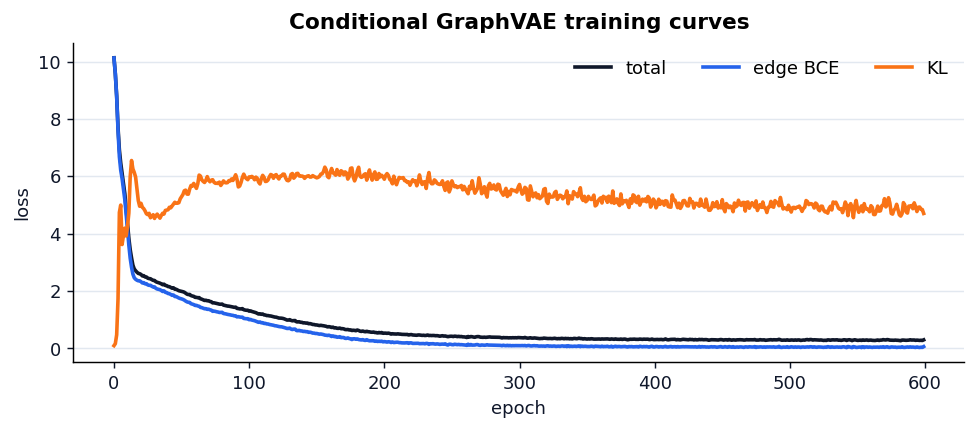

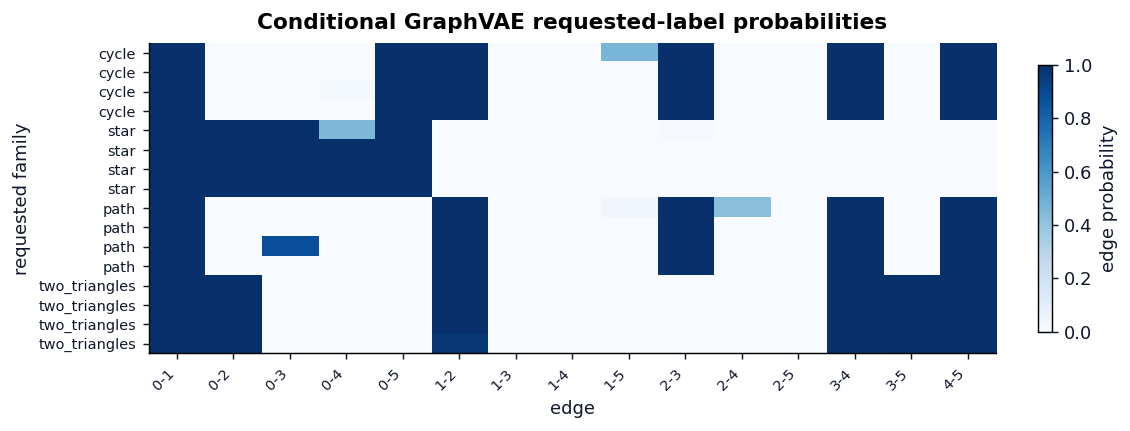

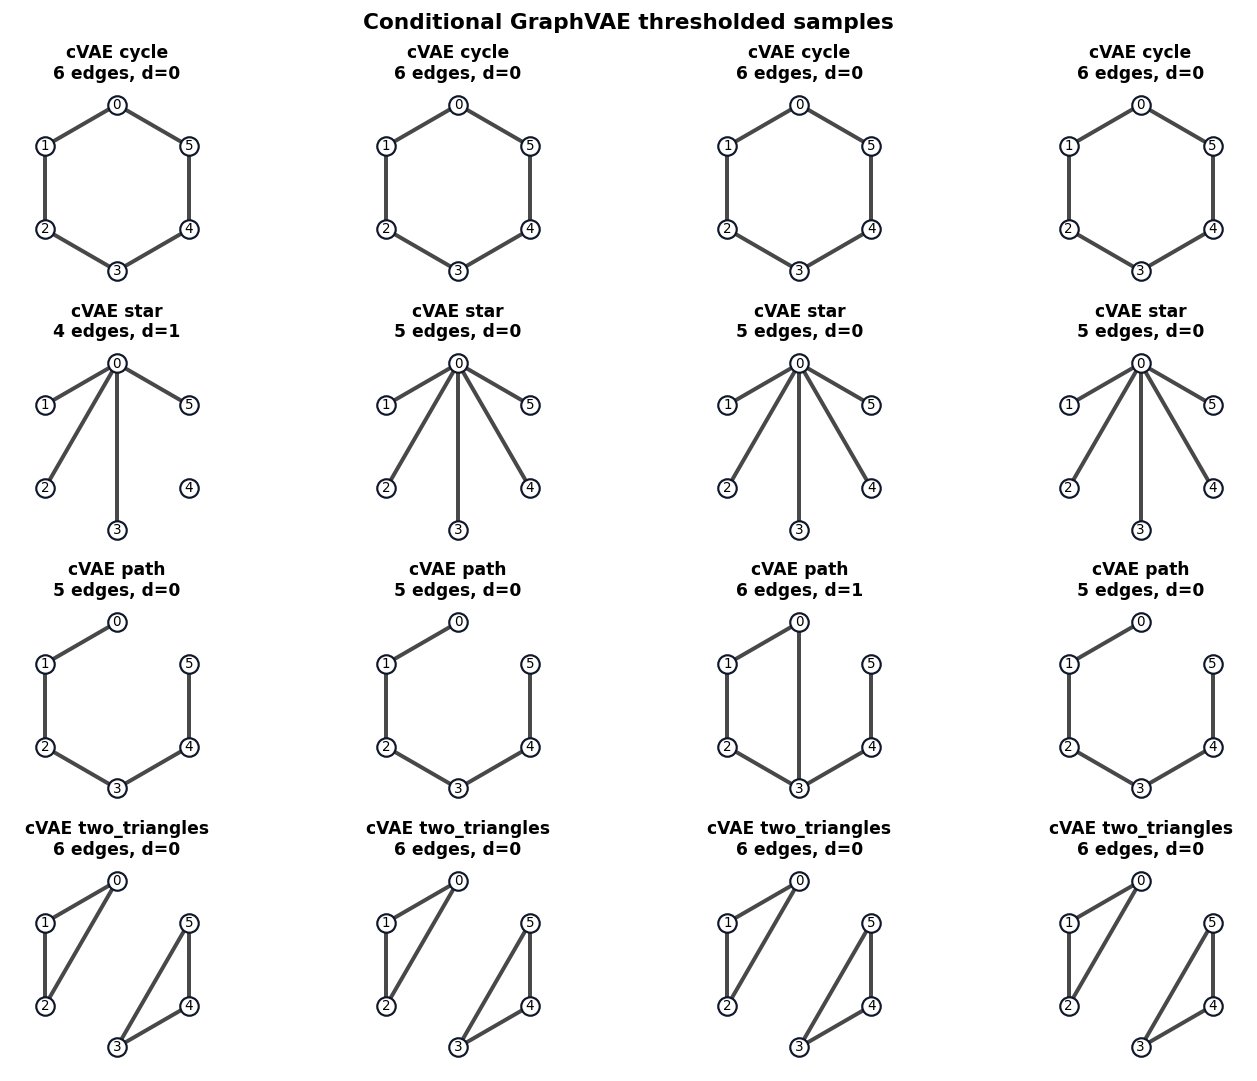

Conditional GraphVAE requested-template diagnostics:
  cycle               : avg edges 6.00, avg Hamming distance 0.00
  star                : avg edges 4.75, avg Hamming distance 0.25
  path                : avg edges 5.25, avg Hamming distance 0.25
  two_triangles       : avg edges 6.00, avg Hamming distance 0.00


In [11]:

def one_hot(labels, n_classes=len(kinds)):
    return F.one_hot(labels, num_classes=n_classes).float()


class ConditionalGraphVAE(nn.Module):
    def __init__(self, n_edges=N_EDGES, latent_dim=8, hidden=64, n_classes=4):
        super().__init__()
        self.n_classes = n_classes
        self.encoder = nn.Sequential(
            nn.Linear(n_edges + n_classes, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu = nn.Linear(hidden, latent_dim)
        self.logvar = nn.Linear(hidden, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_classes, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_edges),
        )

    def encode(self, x, labels):
        y = one_hot(labels, self.n_classes).to(x.device)
        h = self.encoder(torch.cat([x, y], dim=1))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_logits(self, z, labels):
        y = one_hot(labels, self.n_classes).to(z.device)
        return self.decoder(torch.cat([z, y], dim=1))

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_logits(z, labels)
        return logits, mu, logvar


def conditional_vae_loss(logits, x, mu, logvar, beta=0.05):
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kl, recon.detach(), kl.detach()


cvae_latent_dim = 8
cvae = ConditionalGraphVAE(latent_dim=cvae_latent_dim, n_classes=len(kinds)).to(device)
opt_cvae = torch.optim.Adam(cvae.parameters(), lr=1e-3)
cvae_dl = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=128, shuffle=True)
cvae_history = []

for epoch in range(1, 601):
    total_epoch = recon_epoch = kl_epoch = 0.0
    for x_batch, y_batch in cvae_dl:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        logits, mu, logvar = cvae(x_batch, y_batch)
        loss, recon, kl = conditional_vae_loss(logits, x_batch, mu, logvar)
        opt_cvae.zero_grad()
        loss.backward()
        opt_cvae.step()

        batch_size = x_batch.size(0)
        total_epoch += loss.item() * batch_size
        recon_epoch += recon.item() * batch_size
        kl_epoch += kl.item() * batch_size

    cvae_history.append((
        total_epoch / len(cvae_dl.dataset),
        recon_epoch / len(cvae_dl.dataset),
        kl_epoch / len(cvae_dl.dataset),
    ))
    if epoch % 100 == 0:
        total, recon, kl = cvae_history[-1]
        print(f"epoch {epoch:3d} | total {total:.3f} | edge BCE {recon:.3f} | KL {kl:.3f}")

history = np.array(cvae_history)
fig, ax = plt.subplots(figsize=(7.4, 3.2), constrained_layout=True)
ax.plot(history[:, 0], label="total", color=PALETTE["dark"], linewidth=2)
ax.plot(history[:, 1], label="edge BCE", color=PALETTE["blue"], linewidth=2)
ax.plot(history[:, 2], label="KL", color=PALETTE["orange"], linewidth=2)
finish_axis(ax, "Conditional GraphVAE training curves", "epoch", "loss")
ax.legend(ncol=3, loc="upper right")
plt.show()

# Request four samples from each graph family.
cvae.eval()
requested_labels = torch.arange(len(kinds), device=device).repeat_interleave(4)
with torch.no_grad():
    z = torch.randn(len(requested_labels), cvae_latent_dim, device=device)
    cvae_probs = torch.sigmoid(cvae.decode_logits(z, requested_labels)).cpu().numpy()

cvae_hard = (cvae_probs >= 0.5).astype(np.float32)
requested_labels_np = requested_labels.cpu().numpy()
template_vectors = np.stack([adj_to_vec(base_graph(kind)) for kind in kinds])
requested_distance = np.abs(cvae_hard - template_vectors[requested_labels_np]).sum(axis=1)

fig, ax = plt.subplots(figsize=(8.6, 3.2), constrained_layout=True)
im = ax.imshow(cvae_probs, aspect="auto", cmap="Blues", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="edge probability", shrink=0.86)
ax.set_xticks(range(N_EDGES))
ax.set_xticklabels(EDGE_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(requested_labels_np)))
ax.set_yticklabels([kinds[label] for label in requested_labels_np], fontsize=8)
finish_axis(ax, "Conditional GraphVAE requested-label probabilities", "edge", "requested family", grid=False)
plt.show()

cvae_graphs = [vec_to_adj(cvae_hard[i]) for i in range(len(cvae_hard))]
cvae_titles = [
    f"cVAE {kinds[requested_labels_np[i]]}\n{int(cvae_hard[i].sum())} edges, d={int(requested_distance[i])}"
    for i in range(len(cvae_hard))
]
plot_graph_grid(cvae_graphs, titles=cvae_titles, cols=4, figsize=(10.5, 8.2), title="Conditional GraphVAE thresholded samples")

print("Conditional GraphVAE requested-template diagnostics:")
for label, kind in enumerate(kinds):
    mask = requested_labels_np == label
    print(
        f"  {kind:20s}: avg edges {cvae_hard[mask].sum(axis=1).mean():.2f}, "
        f"avg Hamming distance {requested_distance[mask].mean():.2f}"
    )


---
## Part 5 — Topology-only GraphGAN

A GAN replaces likelihood training with an adversarial game between a **generator** and a **discriminator** (critic):

- **Generator**: sample a latent vector and propose a graph.
  $$z \sim \mathcal{N}(0, I), \qquad \tilde{x} = G_\theta(z).$$

- **Discriminator**: score whether an input graph looks real.
  $s = D_\phi(x) \in \mathbb{R}, \qquad \text{(larger } s \Rightarrow \text{“more real”)}.$ 

### What is the “graph” here?

For a topology-only graph with a fixed node ordering, we represent the graph as a length-`N_EDGES` **edge vector**

$$x \in \{0,1\}^{N_{\text{edges}}}, \qquad x_k = A_{ij} \text{ for one upper-triangular pair } (i,j).$$

### Generator output (edge logits → edge probabilities)

The generator outputs **edge logits**:

$$\ell(z) = G_\theta(z) \in \mathbb{R}^{N_{\text{edges}}}, \qquad \pi(z) = \sigma(\ell(z)) \in (0,1)^{N_{\text{edges}}}.$$

At evaluation time we can make a hard sample by Bernoulli sampling (or thresholding):

$$\tilde{x}_k \sim \mathrm{Bernoulli}(\pi_k(z)) \quad \text{or} \quad \tilde{x}_k = \mathbf{1}[\pi_k(z) \ge 0.5].$$

During training, Bernoulli sampling is not differentiable, so we feed the discriminator the **soft** edge-probability vector

$$x_{\text{fake}} = \pi(z) \in (0,1)^{N_{\text{edges}}}.$$

### Losses used in the code (non-saturating GAN with logits)

The discriminator outputs a single logit `D(x)` and we use `BCEWithLogitsLoss`.

- Discriminator update (real vs. fake):
  $$\mathcal{L}_D = \tfrac{1}{2}\,\Big[\mathrm{BCE}(D(x_{\text{real}}), 1) + \mathrm{BCE}(D(x_{\text{fake}}^{\text{detach}}), 0)\Big].$$

- Generator update (try to look real):
  $$\mathcal{L}_{G,\text{adv}} = \mathrm{BCE}(D(x_{\text{fake}}), 1).$$

### Stabilizers for the tiny toy dataset

This notebook also includes two practical stabilizers:

1. **Several generator updates per discriminator update** (`g_steps_per_d > 1`).
2. **Feature matching on edge frequencies** (match the mean edge-probability vector):
   $$\mathcal{L}_{\text{FM}} = \|\mathbb{E}[x_{\text{fake}}] - \mathbb{E}[x_{\text{real}}]\|_2^2.$$

The final generator loss is:

$$\mathcal{L}_G = \mathcal{L}_{G,\text{adv}} + \lambda_{\text{FM}}\,\mathcal{L}_{\text{FM}}.$$

We also use **label smoothing** for real examples (e.g., `real_label=0.9`) and a small amount of **input noise** to make the discriminator less brittle early in training.


In [12]:
# GraphGAN components.
# - Generator G(z) outputs edge logits of shape (B, N_EDGES).
# - Discriminator D(x) takes a (soft) edge vector x in [0,1]^(N_EDGES) and outputs a real/fake logit of shape (B, 1).
#   (This toy setup assumes a fixed node ordering; no permutation invariance is enforced.)


class GraphGenerator(nn.Module):
    def __init__(self, latent_dim=16, n_edges=N_EDGES, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden // 2), nn.LeakyReLU(0.2),
            nn.Linear(hidden // 2, n_edges),
        )

    def forward(self, z):
        return self.net(z)


class GraphDiscriminator(nn.Module):
    def __init__(self, n_edges=N_EDGES, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_edges, hidden), nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


latent_dim = 16
G = GraphGenerator(latent_dim=latent_dim).to(device)
D = GraphDiscriminator().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=8e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce_logits = nn.BCEWithLogitsLoss()


epoch  100 | D loss 0.621 | G loss 0.760 | FM 0.0080 | soft edges 4.66
epoch  200 | D loss 0.615 | G loss 0.742 | FM 0.0033 | soft edges 4.99
epoch  300 | D loss 0.612 | G loss 0.743 | FM 0.0044 | soft edges 5.10
epoch  400 | D loss 0.635 | G loss 0.818 | FM 0.0168 | soft edges 5.57
epoch  500 | D loss 0.605 | G loss 0.745 | FM 0.0024 | soft edges 4.88
epoch  600 | D loss 0.591 | G loss 0.772 | FM 0.0041 | soft edges 4.57
epoch  700 | D loss 0.584 | G loss 0.795 | FM 0.0035 | soft edges 4.77
epoch  800 | D loss 0.548 | G loss 0.870 | FM 0.0054 | soft edges 5.03
epoch  900 | D loss 0.440 | G loss 1.486 | FM 0.0559 | soft edges 5.96
epoch 1000 | D loss 0.544 | G loss 0.983 | FM 0.0252 | soft edges 4.87


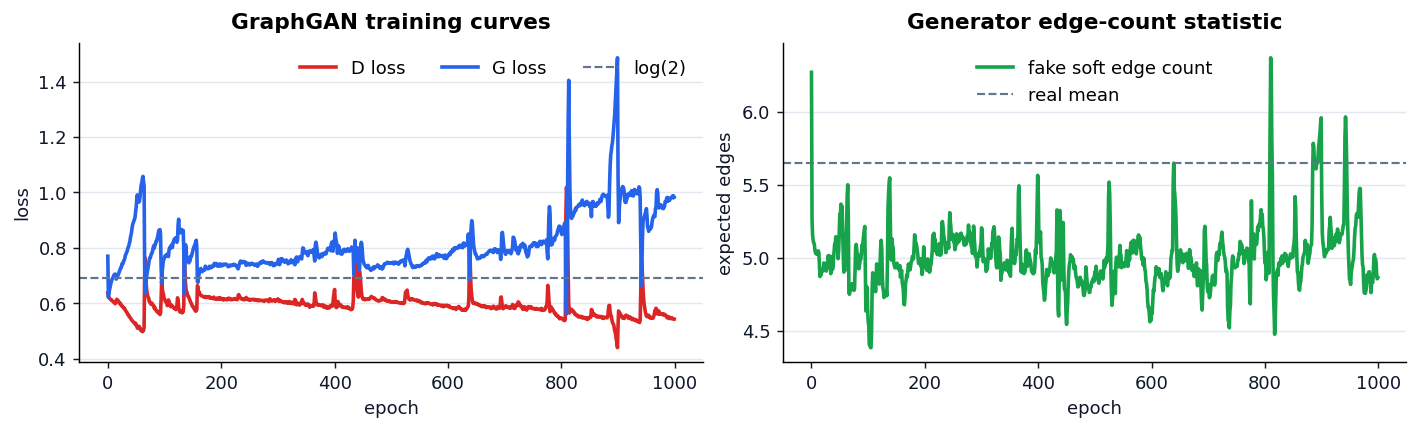

In [13]:

# Train a small GraphGAN. Give the generator several updates for every discriminator update.
gan_dl = DataLoader(TensorDataset(X_tensor), batch_size=128, shuffle=True, drop_last=True)
d_losses, g_losses, fm_losses, fake_edge_counts = [], [], [], []

g_steps_per_d = 4
feature_matching_weight = 4.0
real_label, fake_label = 0.9, 0.0

for epoch in range(1, 1001):
    d_epoch = g_epoch = fm_epoch = edge_count_epoch = 0.0
    g_updates = 0
    # Small input noise makes D less brittle early in training, then fades out.
    noise_std = max(0.03 * (1 - epoch / 500), 0.0)

    for (real,) in gan_dl:
        real = real.to(device)
        B = real.size(0)
        real_y = torch.full((B, 1), real_label, device=device)
        fake_y = torch.full((B, 1), fake_label, device=device)

        # Train D once: real graphs vs. detached soft fake graphs.
        z = torch.randn(B, latent_dim, device=device)
        fake_soft = torch.sigmoid(G(z)).detach()
        real_for_D = torch.clamp(real + noise_std * torch.randn_like(real), 0, 1)
        fake_for_D = torch.clamp(fake_soft + noise_std * torch.randn_like(fake_soft), 0, 1)
        loss_D = 0.5 * (bce_logits(D(real_for_D), real_y) + bce_logits(D(fake_for_D), fake_y))
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        d_epoch += loss_D.item() * B

        # Train G several times so it can catch up to D.
        for _ in range(g_steps_per_d):
            z = torch.randn(B, latent_dim, device=device)
            fake_soft = torch.sigmoid(G(z))
            adv_loss = bce_logits(D(fake_soft), torch.ones(B, 1, device=device))

            # Feature matching stabilizes this tiny discrete GAN by matching edge frequencies.
            fm_loss = F.mse_loss(fake_soft.mean(dim=0), real.mean(dim=0))
            loss_G = adv_loss + feature_matching_weight * fm_loss

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            g_epoch += loss_G.item() * B
            fm_epoch += fm_loss.item() * B
            edge_count_epoch += fake_soft.sum(dim=1).mean().item() * B
            g_updates += 1

    d_losses.append(d_epoch / len(gan_dl.dataset))
    g_losses.append(g_epoch / (len(gan_dl.dataset) * g_steps_per_d))
    fm_losses.append(fm_epoch / (len(gan_dl.dataset) * g_steps_per_d))
    fake_edge_counts.append(edge_count_epoch / (len(gan_dl.dataset) * g_steps_per_d))

    if epoch % 100 == 0:
        print(
            f"epoch {epoch:4d} | D loss {d_losses[-1]:.3f} | G loss {g_losses[-1]:.3f} | "
            f"FM {fm_losses[-1]:.4f} | soft edges {fake_edge_counts[-1]:.2f}"
        )

fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.2), constrained_layout=True)
axes[0].plot(d_losses, label="D loss", color=PALETTE["red"], linewidth=2)
axes[0].plot(g_losses, label="G loss", color=PALETTE["blue"], linewidth=2)
axes[0].axhline(np.log(2), color=PALETTE["gray"], linestyle="--", linewidth=1.2, label="log(2)")
finish_axis(axes[0], "GraphGAN training curves", "epoch", "loss")
axes[0].legend(ncol=3, loc="upper right")

axes[1].plot(fake_edge_counts, label="fake soft edge count", color=PALETTE["green"], linewidth=2)
axes[1].axhline(X_graph.sum(axis=1).mean(), color=PALETTE["gray"], linestyle="--", linewidth=1.2, label="real mean")
finish_axis(axes[1], "Generator edge-count statistic", "epoch", "expected edges")
axes[1].legend(loc="best")
plt.show()


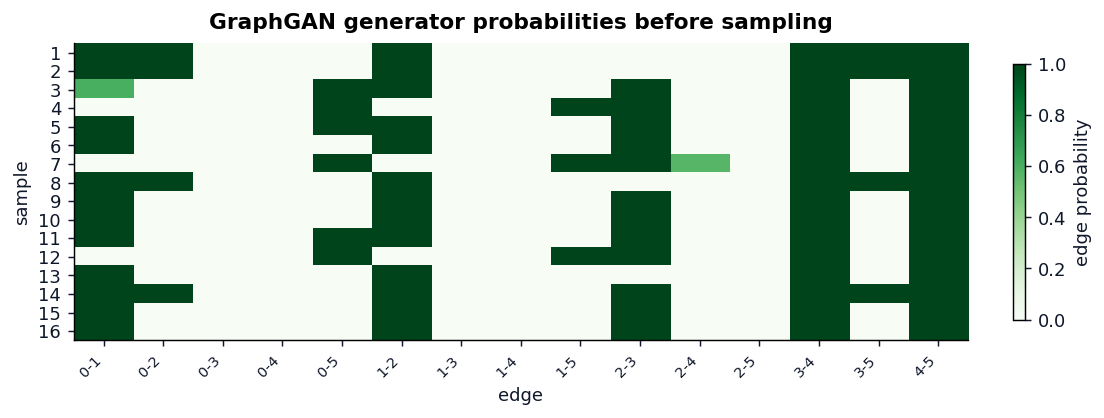

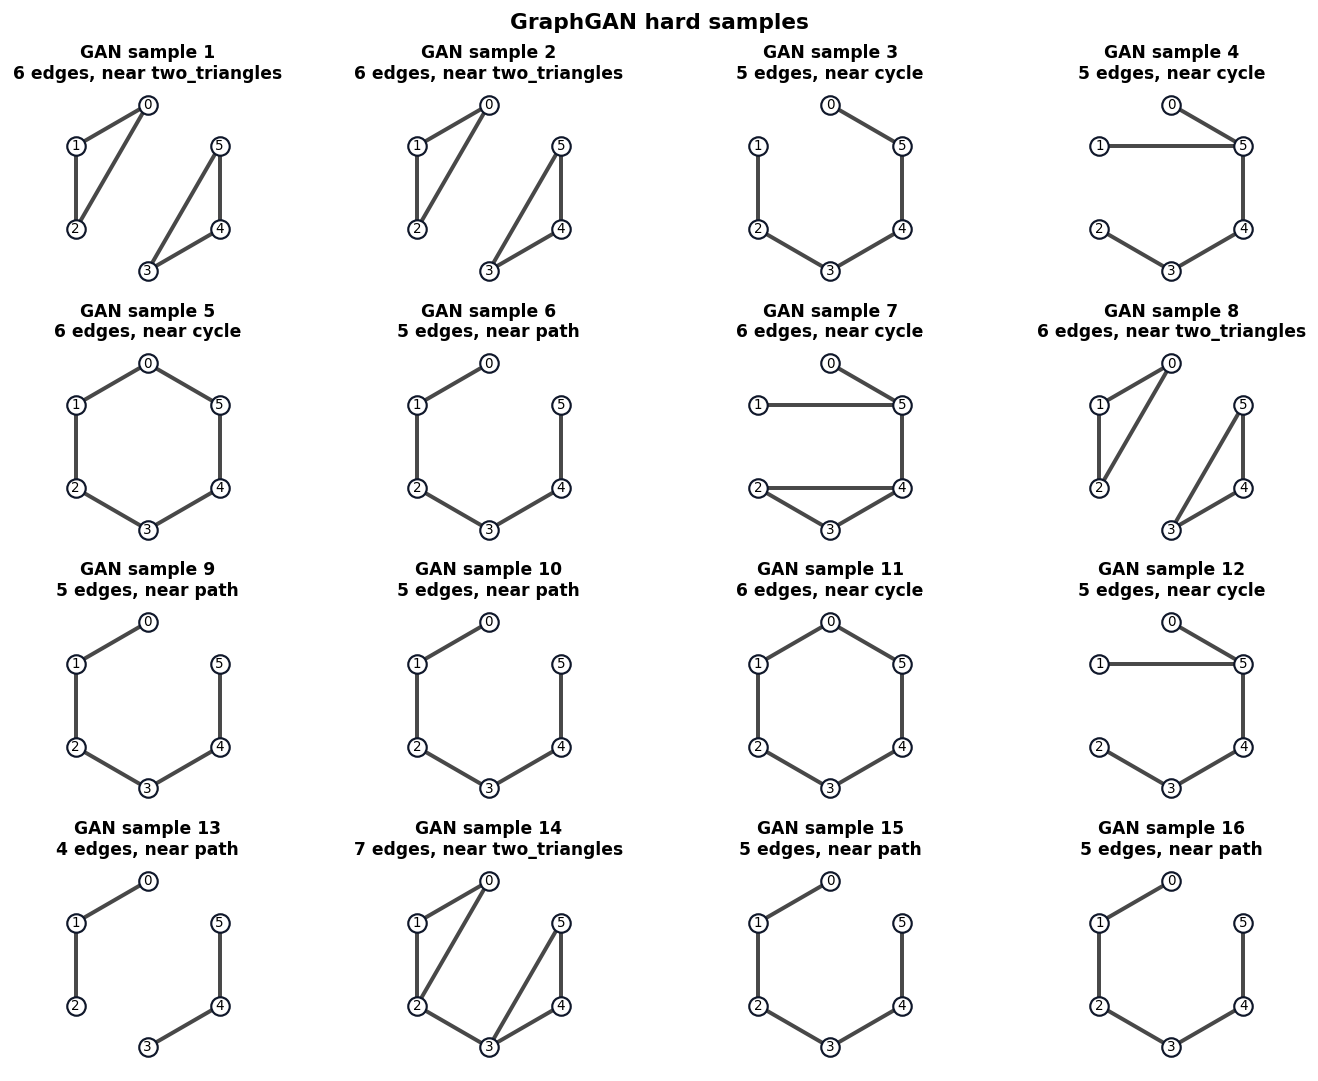

Average real edge count:           5.65
Average GraphGAN probability sum:  5.45
Average GraphGAN sampled edges:    5.44
Sampled edge-count range:          4 to 7
Nearest template counts:
  cycle               : 6
  star                : 0
  path                : 6
  two_triangles       : 4
Average Hamming distance to nearest template: 0.81


In [14]:

# Generate GraphGAN samples.
G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    probs = torch.sigmoid(G(z)).cpu().numpy()

rng = np.random.default_rng(123)
hard = (rng.random(probs.shape) < probs).astype(np.float32)

template_vectors = np.stack([adj_to_vec(base_graph(kind)) for kind in kinds])
template_distances = np.abs(hard[:, None, :] - template_vectors[None, :, :]).sum(axis=2)
nearest_template = template_distances.argmin(axis=1)
nearest_distance = template_distances.min(axis=1)

fig, ax = plt.subplots(figsize=(8.4, 3.1), constrained_layout=True)
im = ax.imshow(probs, aspect="auto", cmap="Greens", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="edge probability", shrink=0.86)
ax.set_xticks(range(N_EDGES))
ax.set_xticklabels(EDGE_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(probs.shape[0]))
ax.set_yticklabels([str(i + 1) for i in range(probs.shape[0])])
finish_axis(ax, "GraphGAN generator probabilities before sampling", "edge", "sample", grid=False)
plt.show()

gan_graphs = [vec_to_adj(hard[i]) for i in range(hard.shape[0])]
gan_titles = [
    f"GAN sample {i + 1}\n{int(hard[i].sum())} edges, near {kinds[nearest_template[i]]}"
    for i in range(hard.shape[0])
]
plot_graph_grid(gan_graphs, titles=gan_titles, cols=4, figsize=(10.5, 8.2), title="GraphGAN hard samples")

real_edge_counts = X_graph.sum(axis=1)
fake_edge_counts_sampled = hard.sum(axis=1)
nearest_counts = np.bincount(nearest_template, minlength=len(kinds))

print("Average real edge count:          ", real_edge_counts.mean().round(2))
print("Average GraphGAN probability sum: ", probs.sum(axis=1).mean().round(2))
print("Average GraphGAN sampled edges:   ", fake_edge_counts_sampled.mean().round(2))
print("Sampled edge-count range:         ", int(fake_edge_counts_sampled.min()), "to", int(fake_edge_counts_sampled.max()))
print("Nearest template counts:")
for kind, count in zip(kinds, nearest_counts):
    print(f"  {kind:20s}: {count}")
print("Average Hamming distance to nearest template:", nearest_distance.mean().round(2))


### Part 5.2 — Conditional topology-only GraphGAN

A conditional GAN gives the requested topology label to both players:

$$G_\theta(z, y) \rightarrow \tilde{x}, \qquad D_\phi(x, y) \rightarrow \text{real/fake score}.$$

In this toy setting the label is a discrete family index $y \in \{0,\dots,C-1\}$, so we pass a one-hot vector to both networks.

- Generator: concatenate $z$ and one-hot$(y)$, then output edge logits and probabilities:
  $$\ell = G_\theta([z, \mathrm{onehot}(y)]), \qquad x_{\text{fake}} = \sigma(\ell).$$

- Discriminator: concatenate the edge vector with one-hot$(y)$ and output a logit score:
  $$s = D_\phi([x, \mathrm{onehot}(y)]).$$

The losses are the same BCE-with-logits GAN losses as above, just conditioned on $y$. At sampling time you choose a label $y$ (e.g., “cycle” vs “star”) and the generator produces graphs consistent with that family.


epoch 100 | cD loss 0.588 | cG loss 0.766 | class FM 0.0023 | hard-template d 0.00
epoch 200 | cD loss 0.603 | cG loss 0.782 | class FM 0.0113 | hard-template d 0.16
epoch 300 | cD loss 0.581 | cG loss 0.846 | class FM 0.0115 | hard-template d 0.23
epoch 400 | cD loss 0.575 | cG loss 0.813 | class FM 0.0074 | hard-template d 0.15
epoch 500 | cD loss 0.587 | cG loss 0.839 | class FM 0.0083 | hard-template d 0.20
epoch 600 | cD loss 0.808 | cG loss 0.687 | class FM 0.0486 | hard-template d 0.94
epoch 700 | cD loss 0.571 | cG loss 0.791 | class FM 0.0024 | hard-template d 0.01
epoch 800 | cD loss 0.620 | cG loss 1.137 | class FM 0.0664 | hard-template d 1.09
Restored best conditional generator from epoch 5 with hard-template d 0.00


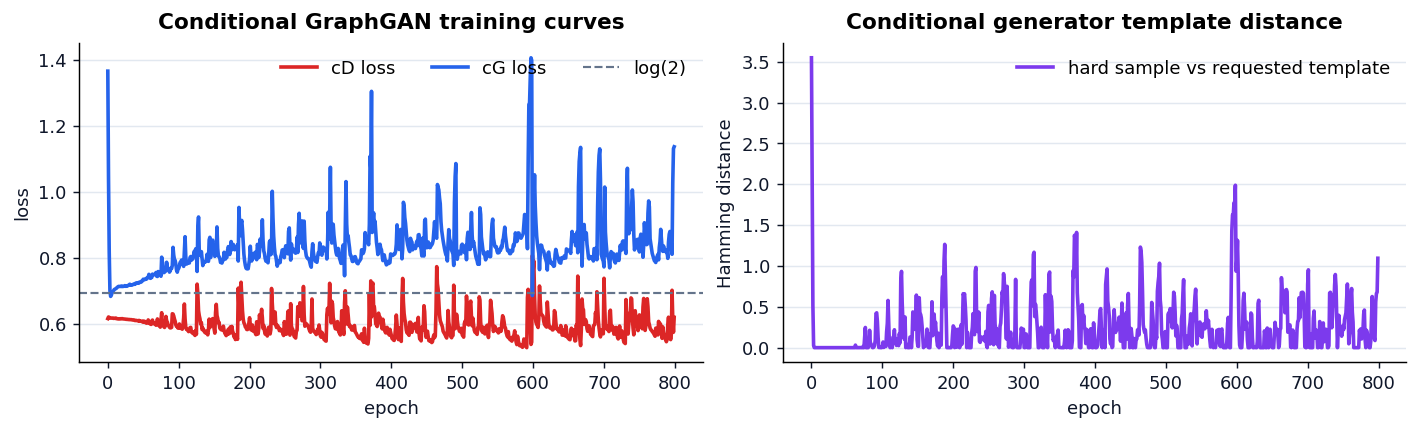

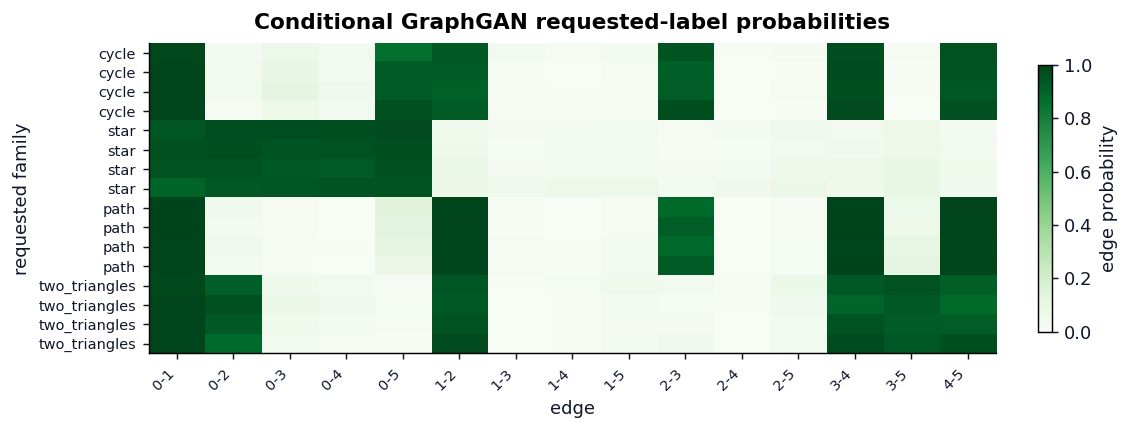

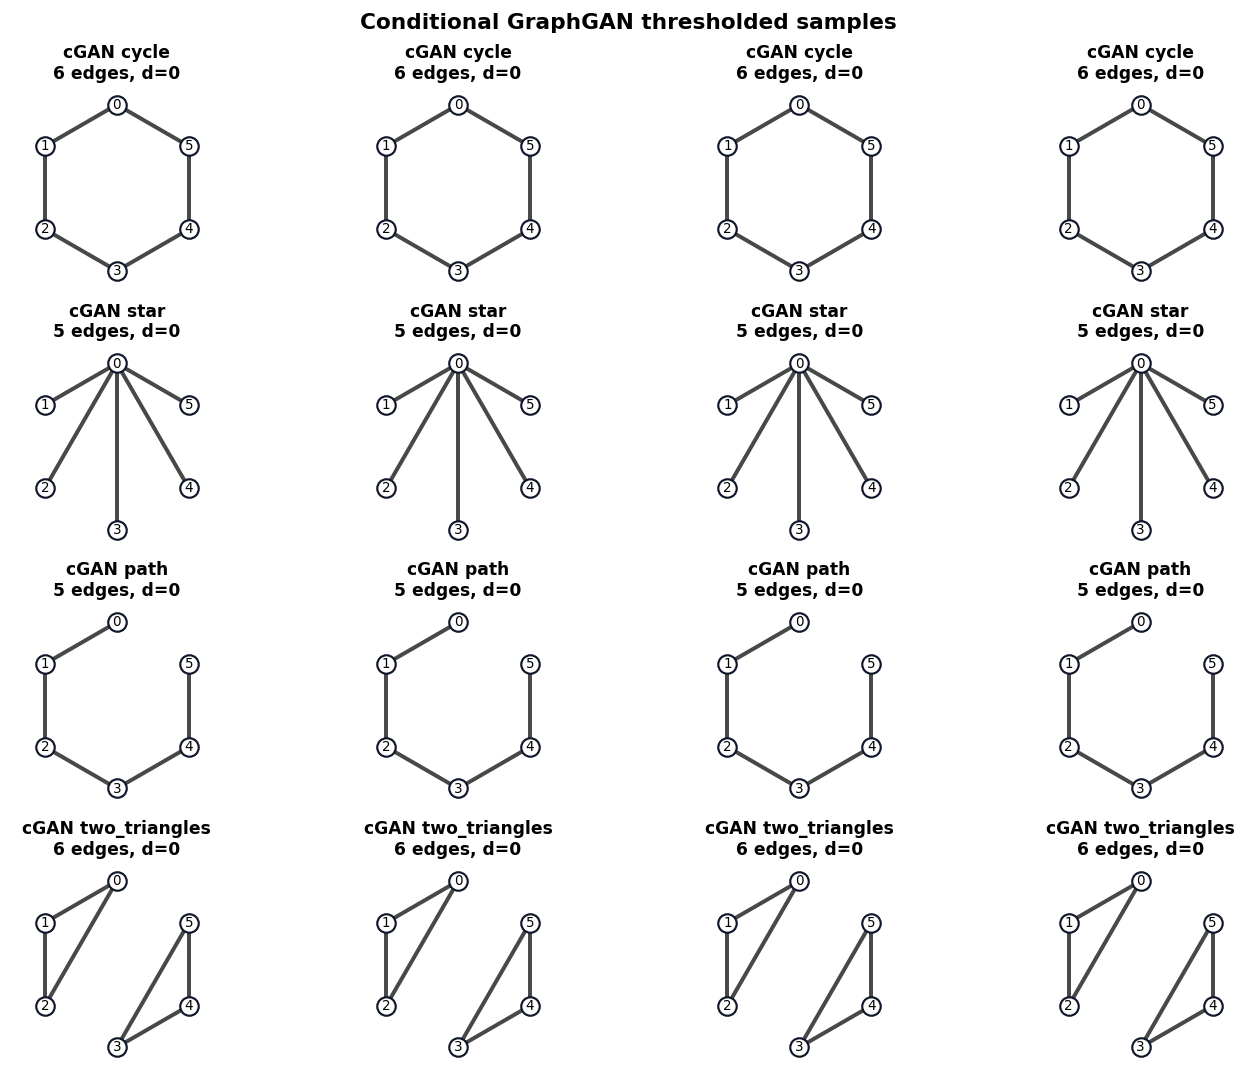

Conditional GraphGAN requested-template diagnostics:
  cycle               : avg edges 6.00, avg Hamming distance 0.00
  star                : avg edges 5.00, avg Hamming distance 0.00
  path                : avg edges 5.00, avg Hamming distance 0.00
  two_triangles       : avg edges 6.00, avg Hamming distance 0.00


In [15]:

class ConditionalGraphGenerator(nn.Module):
    def __init__(self, latent_dim=16, n_edges=N_EDGES, hidden=128, n_classes=4):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Linear(latent_dim + n_classes, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden // 2), nn.LeakyReLU(0.2),
            nn.Linear(hidden // 2, n_edges),
        )

    def forward(self, z, labels):
        y = one_hot(labels, self.n_classes).to(z.device)
        return self.net(torch.cat([z, y], dim=1))


class ConditionalGraphDiscriminator(nn.Module):
    def __init__(self, n_edges=N_EDGES, hidden=64, n_classes=4):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Linear(n_edges + n_classes, hidden), nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, labels):
        y = one_hot(labels, self.n_classes).to(x.device)
        return self.net(torch.cat([x, y], dim=1))


conditional_latent_dim = 16
cG = ConditionalGraphGenerator(latent_dim=conditional_latent_dim, n_classes=len(kinds)).to(device)
cD = ConditionalGraphDiscriminator(n_classes=len(kinds)).to(device)
opt_cG = torch.optim.Adam(cG.parameters(), lr=8e-4, betas=(0.5, 0.999))
opt_cD = torch.optim.Adam(cD.parameters(), lr=2e-4, betas=(0.5, 0.999))

class_edge_means = torch.stack([
    X_tensor[y_tensor == label].mean(dim=0)
    for label in range(len(kinds))
]).to(device)

cgan_dl = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=128, shuffle=True, drop_last=True)
c_d_losses, c_g_losses, c_fm_losses, c_hamming_losses = [], [], [], []
best_cG_state = None
best_hamming = float("inf")
best_epoch = 0

g_steps_per_d = 4
class_feature_matching_weight = 5.0
real_label, fake_label = 0.9, 0.0

for epoch in range(1, 801):
    d_epoch = g_epoch = fm_epoch = hamming_epoch = 0.0
    noise_std = max(0.03 * (1 - epoch / 400), 0.0)

    for x_batch, y_batch in cgan_dl:
        real = x_batch.to(device)
        labels = y_batch.to(device)
        B = real.size(0)
        real_y = torch.full((B, 1), real_label, device=device)
        fake_y = torch.full((B, 1), fake_label, device=device)

        # Train conditional D once.
        z = torch.randn(B, conditional_latent_dim, device=device)
        fake_soft = torch.sigmoid(cG(z, labels)).detach()
        real_for_D = torch.clamp(real + noise_std * torch.randn_like(real), 0, 1)
        fake_for_D = torch.clamp(fake_soft + noise_std * torch.randn_like(fake_soft), 0, 1)
        loss_D = 0.5 * (
            bce_logits(cD(real_for_D, labels), real_y)
            + bce_logits(cD(fake_for_D, labels), fake_y)
        )
        opt_cD.zero_grad()
        loss_D.backward()
        opt_cD.step()
        d_epoch += loss_D.item() * B

        # Train conditional G several times using uniformly sampled requested labels.
        for _ in range(g_steps_per_d):
            requested = torch.randint(0, len(kinds), (B,), device=device)
            z = torch.randn(B, conditional_latent_dim, device=device)
            fake_soft = torch.sigmoid(cG(z, requested))
            adv_loss = bce_logits(cD(fake_soft, requested), torch.ones(B, 1, device=device))

            # Class-conditional feature matching: match edge frequencies for the requested family.
            target_edges = class_edge_means[requested]
            fm_loss = F.mse_loss(fake_soft, target_edges)
            loss_G = adv_loss + class_feature_matching_weight * fm_loss

            opt_cG.zero_grad()
            loss_G.backward()
            opt_cG.step()

            g_epoch += loss_G.item() * B
            fm_epoch += fm_loss.item() * B
            hamming_epoch += torch.abs((fake_soft >= 0.5).float() - target_edges.round()).sum(dim=1).mean().item() * B

    denom = len(cgan_dl.dataset) * g_steps_per_d
    c_d_losses.append(d_epoch / len(cgan_dl.dataset))
    c_g_losses.append(g_epoch / denom)
    c_fm_losses.append(fm_epoch / denom)
    c_hamming_losses.append(hamming_epoch / denom)

    if c_hamming_losses[-1] < best_hamming:
        best_hamming = c_hamming_losses[-1]
        best_epoch = epoch
        best_cG_state = {key: value.detach().cpu().clone() for key, value in cG.state_dict().items()}

    if epoch % 100 == 0:
        print(
            f"epoch {epoch:3d} | cD loss {c_d_losses[-1]:.3f} | cG loss {c_g_losses[-1]:.3f} | "
            f"class FM {c_fm_losses[-1]:.4f} | hard-template d {c_hamming_losses[-1]:.2f}"
        )

if best_cG_state is not None:
    cG.load_state_dict({key: value.to(device) for key, value in best_cG_state.items()})
    print(f"Restored best conditional generator from epoch {best_epoch} with hard-template d {best_hamming:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.2), constrained_layout=True)
axes[0].plot(c_d_losses, label="cD loss", color=PALETTE["red"], linewidth=2)
axes[0].plot(c_g_losses, label="cG loss", color=PALETTE["blue"], linewidth=2)
axes[0].axhline(np.log(2), color=PALETTE["gray"], linestyle="--", linewidth=1.2, label="log(2)")
finish_axis(axes[0], "Conditional GraphGAN training curves", "epoch", "loss")
axes[0].legend(ncol=3, loc="upper right")

axes[1].plot(c_hamming_losses, label="hard sample vs requested template", color=PALETTE["purple"], linewidth=2)
finish_axis(axes[1], "Conditional generator template distance", "epoch", "Hamming distance")
axes[1].legend(loc="best")
plt.show()

# Request four samples from each graph family.
cG.eval()
requested_labels = torch.arange(len(kinds), device=device).repeat_interleave(4)
with torch.no_grad():
    z = torch.randn(len(requested_labels), conditional_latent_dim, device=device)
    cgan_probs = torch.sigmoid(cG(z, requested_labels)).cpu().numpy()

cgan_hard = (cgan_probs >= 0.5).astype(np.float32)
requested_labels_np = requested_labels.cpu().numpy()
template_vectors = np.stack([adj_to_vec(base_graph(kind)) for kind in kinds])
requested_distance = np.abs(cgan_hard - template_vectors[requested_labels_np]).sum(axis=1)

fig, ax = plt.subplots(figsize=(8.6, 3.2), constrained_layout=True)
im = ax.imshow(cgan_probs, aspect="auto", cmap="Greens", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="edge probability", shrink=0.86)
ax.set_xticks(range(N_EDGES))
ax.set_xticklabels(EDGE_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(requested_labels_np)))
ax.set_yticklabels([kinds[label] for label in requested_labels_np], fontsize=8)
finish_axis(ax, "Conditional GraphGAN requested-label probabilities", "edge", "requested family", grid=False)
plt.show()

cgan_graphs = [vec_to_adj(cgan_hard[i]) for i in range(len(cgan_hard))]
cgan_titles = [
    f"cGAN {kinds[requested_labels_np[i]]}\n{int(cgan_hard[i].sum())} edges, d={int(requested_distance[i])}"
    for i in range(len(cgan_hard))
]
plot_graph_grid(cgan_graphs, titles=cgan_titles, cols=4, figsize=(10.5, 8.2), title="Conditional GraphGAN thresholded samples")

print("Conditional GraphGAN requested-template diagnostics:")
for label, kind in enumerate(kinds):
    mask = requested_labels_np == label
    print(
        f"  {kind:20s}: avg edges {cgan_hard[mask].sum(axis=1).mean():.2f}, "
        f"avg Hamming distance {requested_distance[mask].mean():.2f}"
    )


---
## Part 6 — Topology-only discrete diffusion

For images, DDPM uses Gaussian corruption:

$$x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon.$$

For discrete data, adding Gaussian noise to a token ID or an edge indicator is not natural. Instead, we define a discrete corruption process.

Examples:

| Domain | Forward noising idea | Reverse model predicts |
|---|---|---|
| Language | randomly mask or replace tokens | token distribution |
| Graph edges | randomly flip/mask edges | Bernoulli edge probabilities |
| Node labels | replace labels with random categories | categorical node distribution |

### Forward (noising) process used in the code

For topology-only binary graph edges, each graph is a length-`N_EDGES` binary vector

$$x \in \{0,1\}^{N_{\text{edges}}}.$$

The forward process is a **Markov chain** that flips each edge independently at each step:

$$q(x_t \mid x_{t-1}): \quad x_t = x_{t-1} \oplus \eta_t, \qquad \eta_t \sim \mathrm{Bernoulli}(\beta_t).$$

**Equation-to-code view of one forward step.** In the code, a minibatch of graphs has shape

$$x_{t-1} \in \{0,1\}^{B \times E},$$

where $B$ is the batch size and $E=N_{\text{edges}}$. In this notebook, $N_{\text{nodes}}=6$, so

$$E=\binom{6}{2}=15.$$

For every graph $b \in \{1,\dots,B\}$ and every possible edge $e \in \{1,\dots,E\}$, the forward step samples an independent flip variable

$$\eta_{b,e,t} \sim \mathrm{Bernoulli}(\beta_t), \qquad \eta_t \in \{0,1\}^{B \times E}.$$

Then the new noisy edge value is

$$x_{t,b,e}=x_{t-1,b,e}\oplus\eta_{b,e,t}=|x_{t-1,b,e}-\eta_{b,e,t}|.$$

The absolute-value form works because the variables are binary:

| $x_{t-1}$ | $\eta_t$ | $|x_{t-1}-\eta_t|$ | meaning |
|---|---|---|---|
| 0 | 0 | 0 | absent edge stays absent |
| 0 | 1 | 1 | absent edge is added |
| 1 | 0 | 1 | present edge stays present |
| 1 | 1 | 0 | present edge is removed |

So the function

```python
p = betas[t_value]
flips = torch.bernoulli(torch.full_like(x_prev, p))
x_t = torch.abs(x_prev - flips)
```

implements the equations

$$p=\beta_t, \qquad \eta_t\sim\mathrm{Bernoulli}(\beta_t)^{B\times E}, \qquad x_t=|x_{t-1}-\eta_t|.$$

For example, if one graph is represented by five edge entries just for illustration,

$$x_{t-1}=[1,0,0,1,0], \qquad \eta_t=[0,1,0,0,1],$$

then

$$x_t=|x_{t-1}-\eta_t|=[1,1,0,1,1].$$

For a single edge bit $x \in \{0,1\}$, this is the 2×2 transition matrix

$$Q_t = \begin{pmatrix}
1-\beta_t & \beta_t\\
\beta_t & 1-\beta_t
\end{pmatrix}.$$

Because this is a symmetric flip channel, its stationary distribution is uniform; with a schedule that eventually mixes strongly, the marginal approaches

$$q(x_T) \approx \mathrm{Bernoulli}(0.5),$$

so a large-$t$ graph looks like a **random graph with independent edges**.

**Efficiency note:** the code samples $x_t$ directly from $x_0$ using the closed-form marginal $q(x_t\mid x_0)$ for this flip chain (equivalent to a single flip with an effective probability $\bar\beta_t$). This avoids explicitly simulating $t$ sequential steps inside each minibatch.

In code this is `corrupt_edges(x0, t)`.
### What the denoiser learns

We train a neural net to predict the **clean edge vector** from a corrupted one:

$$p_\theta(x_0 \mid x_t, t).$$

Concretely, the denoiser outputs logits for each edge and we use binary cross-entropy to the true $x_0$:

$$\ell_\theta(x_t,t) \in \mathbb{R}^{N_{\text{edges}}}, \qquad \hat{x}_0 = \sigma(\ell_\theta), \qquad \mathcal{L}=\mathrm{BCEWithLogits}(\ell_\theta, x_0).$$

### Training loop (what the code does)

For each minibatch:

1. Sample a clean graph vector $x_0$ from the dataset.
2. Sample a timestep $t \sim \mathrm{Uniform}\{1,\dots,T\}$.
3. Corrupt: $x_t \leftarrow \texttt{corrupt\_edges}(x_0, t)$.
4. Predict: $\ell \leftarrow \texttt{denoiser}(x_t, t)$.
5. Optimize: `BCEWithLogitsLoss(ℓ, x0)`.

### Sampling / generation (how a clean graph is produced)

The helper `reverse_diffuse_edges(...)` implements a simple teaching sampler:

1. Initialize $x_T \sim \mathrm{Bernoulli}(0.5)$ (random edges).
2. For $t = T, T-1, \dots, 1$:
   - Predict clean probabilities: $\hat{x}_0 \leftarrow \sigma(\texttt{model}(x_t, t))$.
   - Make a hard estimate $\tilde{x}_0$ by thresholding (or Bernoulli sampling).
   - To get the next state, we **re-noise** that estimate at the lower noise level:
     $$x_{t-1} \leftarrow \texttt{corrupt\_edges}(\tilde{x}_0, t-1).$$
3. Return the final hard sample $x_0$.

This “predict $x_0$ then re-noise” reverse loop is intentionally simple for clarity; it is not the exact DDPM reverse transition. The notebook also records intermediate $x_t$ values via `trace_steps` so we can visualize the reverse trajectory.


In [16]:
# Discrete diffusion on graph edge vectors: a binary-symmetric flip Markov chain forward process, then learn p(x0|xt,t).
T_disc = 24

# Per-step flip probabilities beta_t for q(x_t | x_{t-1}). (beta_0 is unused / defined as 0.)
betas = torch.linspace(0.0, 0.48, T_disc + 1, device=device)

# For a flip chain, the marginal q(x_t | x0) is also a BSC with an *effective* flip probability:
#   \bar{beta}_t = 0.5 * (1 - prod_{s=1..t} (1 - 2*beta_s)).
one_minus_2b = 1.0 - 2.0 * betas
gamma = torch.cumprod(one_minus_2b, dim=0)  # gamma[t] = prod_{s=0..t}(1-2 beta_s), with gamma[0]=1
flip_marginal = 0.5 * (1.0 - gamma)

def corrupt_edges(x0, t):
    """Sample x_t ~ q(x_t | x0) for the flip Markov chain.

    x0: (B, E) binary. t: (B,) integer timesteps in [1, T_disc].
    Implemented by sampling an effective flip mask with probability flip_marginal[t].
    """
    p = flip_marginal[t].unsqueeze(1)
    flips = torch.bernoulli(torch.ones_like(x0) * p)
    return torch.abs(x0 - flips)

class EdgeDenoiser(nn.Module):
    def __init__(self, n_edges=N_EDGES, hidden=128, t_dim=24):
        super().__init__()
        self.t_embed = nn.Embedding(T_disc + 1, t_dim)
        self.net = nn.Sequential(
            nn.Linear(n_edges + t_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, n_edges),
        )

    def forward(self, xt, t):
        h = torch.cat([xt, self.t_embed(t)], dim=1)
        return self.net(h)


def reverse_diffuse_edges(model, n_samples, labels=None, conditional=False, threshold=True, trace_steps=None, seed=None):
    """Generate samples via a simple reverse loop.

    At each step t: predict x0 probabilities from (xt, t), harden to a clean estimate, then re-noise
    that estimate with the *lower* flip probability for (t-1) to obtain x_{t-1}.
    """
    if seed is not None:
        torch.manual_seed(seed)
    model.eval()
    # Start the reverse chain from random edges (x_T).
    xt = torch.bernoulli(torch.full((n_samples, N_EDGES), 0.5, device=device))
    trace_steps = set(trace_steps or [])
    trace = {T_disc: xt.detach().cpu().numpy()} if T_disc in trace_steps else {}

    if labels is not None and not torch.is_tensor(labels):
        labels = torch.tensor(labels, dtype=torch.long, device=device)
    elif labels is not None:
        labels = labels.to(device)

    with torch.no_grad():
        clean_probs = torch.full_like(xt, 0.5)
        for t_value in range(T_disc, 0, -1):
            t = torch.full((n_samples,), t_value, dtype=torch.long, device=device)
            logits = model(xt, t, labels) if conditional else model(xt, t)
            # Predict clean edge probabilities p(x0|xt,t).
            clean_probs = torch.sigmoid(logits)
            clean_estimate = (clean_probs >= 0.5).float() if threshold else torch.bernoulli(clean_probs)

            if t_value > 1:
                prev_t = torch.full((n_samples,), t_value - 1, dtype=torch.long, device=device)
                # Re-noise the clean estimate at timestep (t-1) to get x_{t-1}.
                xt = corrupt_edges(clean_estimate, prev_t)
            else:
                xt = clean_estimate

            if t_value - 1 in trace_steps:
                trace[t_value - 1] = xt.detach().cpu().numpy()

    return xt.cpu().numpy(), clean_probs.cpu().numpy(), trace


denoiser = EdgeDenoiser().to(device)
opt_den = torch.optim.Adam(denoiser.parameters(), lr=1e-3)


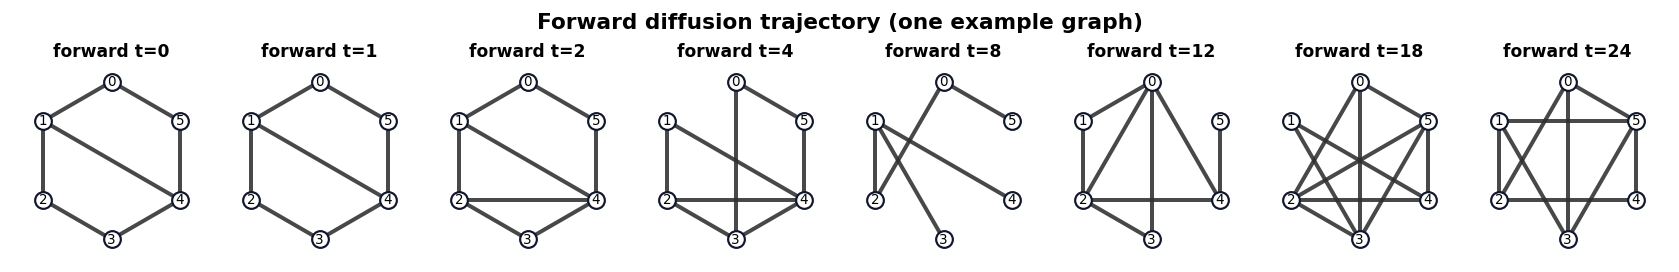

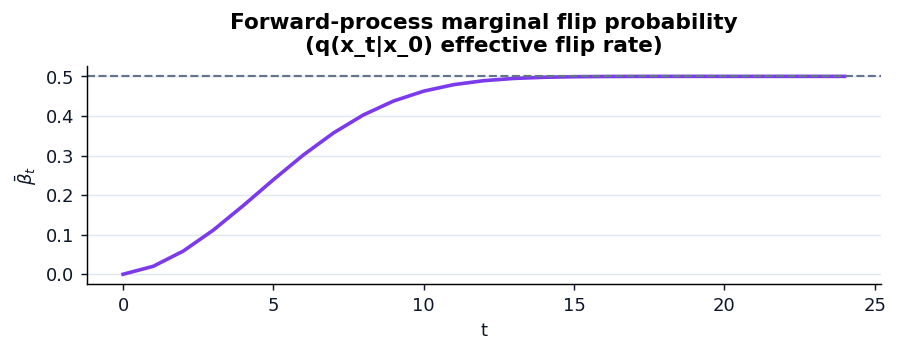

In [17]:
# Visualize the *forward* diffusion process: x0 -> x1 -> ... -> xT
# (Sequential Markov chain using per-step betas.)

def forward_step_edges(x_prev, t_value, seed=None):
    """One forward step x_t ~ q(x_t | x_{t-1}) for the flip chain."""
    if seed is not None:
        torch.manual_seed(seed)
    p = betas[t_value]  # scalar
    flips = torch.bernoulli(torch.full_like(x_prev, p))
    return torch.abs(x_prev - flips)


def forward_trajectory(x0, t_values, seed=0):
    """Return a consistent trajectory by applying per-step transitions sequentially."""
    torch.manual_seed(seed)
    xt = x0.clone()
    traj = {0: xt.clone()}
    for t in range(1, max(t_values) + 1):
        xt = forward_step_edges(xt, t)
        if t in t_values:
            traj[t] = xt.clone()
    return traj


# Pick a clean graph x0 from the dataset and visualize noising over time.
idx0 = int(np.where(y_graph == 0)[0][0])
x0 = X_tensor[idx0:idx0 + 1].to(device)  # (1, E)
t_values = [0, 1, 2, 4, 8, 12, 18, T_disc]
traj = forward_trajectory(x0, t_values=t_values, seed=123)

graphs = [vec_to_adj(traj[t].detach().cpu().numpy()[0]) for t in t_values]
titles = [f"forward t={t}" for t in t_values]
plot_graph_grid(graphs, titles=titles, cols=len(t_values), figsize=(1.6 * len(t_values), 2.1), node_size=0.09,
               title="Forward diffusion trajectory (one example graph)")

# Also visualize how the marginal flip probability approaches 0.5 (random edges).
fig, ax = plt.subplots(figsize=(6.8, 2.6), constrained_layout=True)
ax.plot(flip_marginal.detach().cpu().numpy(), color=PALETTE["purple"], linewidth=2)
ax.axhline(0.5, color=PALETTE["gray"], linestyle="--", linewidth=1.2)
finish_axis(ax, "Forward-process marginal flip probability\n(q(x_t|x_0) effective flip rate)", "t", r"$\bar\beta_t$")
plt.show()


epoch 100 | denoising BCE 0.384
epoch 200 | denoising BCE 0.380
epoch 300 | denoising BCE 0.378
epoch 400 | denoising BCE 0.368
epoch 500 | denoising BCE 0.375
epoch 600 | denoising BCE 0.366
epoch 700 | denoising BCE 0.367
epoch 800 | denoising BCE 0.368
epoch 900 | denoising BCE 0.369
epoch 1000 | denoising BCE 0.380


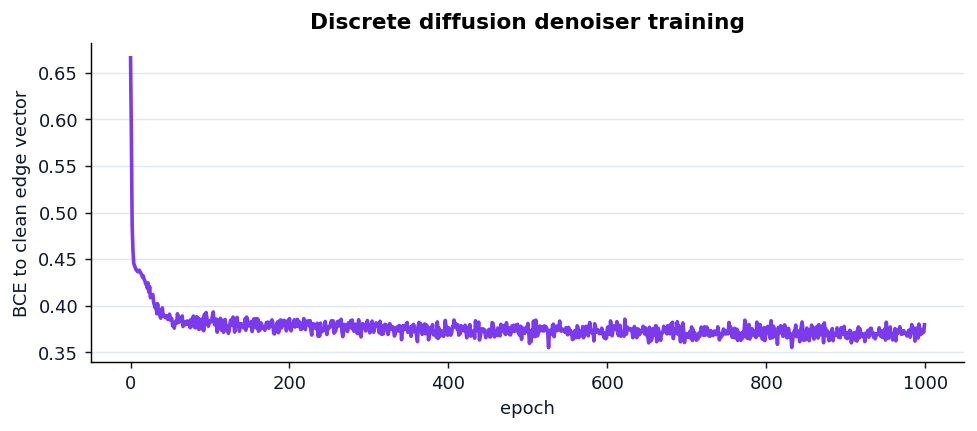

In [18]:

# Train the denoiser to recover x0 from corrupted xt.
diff_dl = DataLoader(TensorDataset(X_tensor), batch_size=128, shuffle=True)
diff_losses = []

for epoch in range(1, 1001):
    epoch_loss = 0.0
    for (x0,) in diff_dl:
        x0 = x0.to(device)
        B = x0.size(0)
        t = torch.randint(1, T_disc + 1, (B,), device=device)
        xt = corrupt_edges(x0, t)
        logits = denoiser(xt, t)
        loss = F.binary_cross_entropy_with_logits(logits, x0)
        opt_den.zero_grad()
        loss.backward()
        opt_den.step()
        epoch_loss += loss.item() * B
    diff_losses.append(epoch_loss / len(diff_dl.dataset))
    if epoch % 100 == 0:
        print(f"epoch {epoch:3d} | denoising BCE {diff_losses[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7.4, 3.2), constrained_layout=True)
ax.plot(diff_losses, color=PALETTE["purple"], linewidth=2)
finish_axis(ax, "Discrete diffusion denoiser training", "epoch", "BCE to clean edge vector")
plt.show()


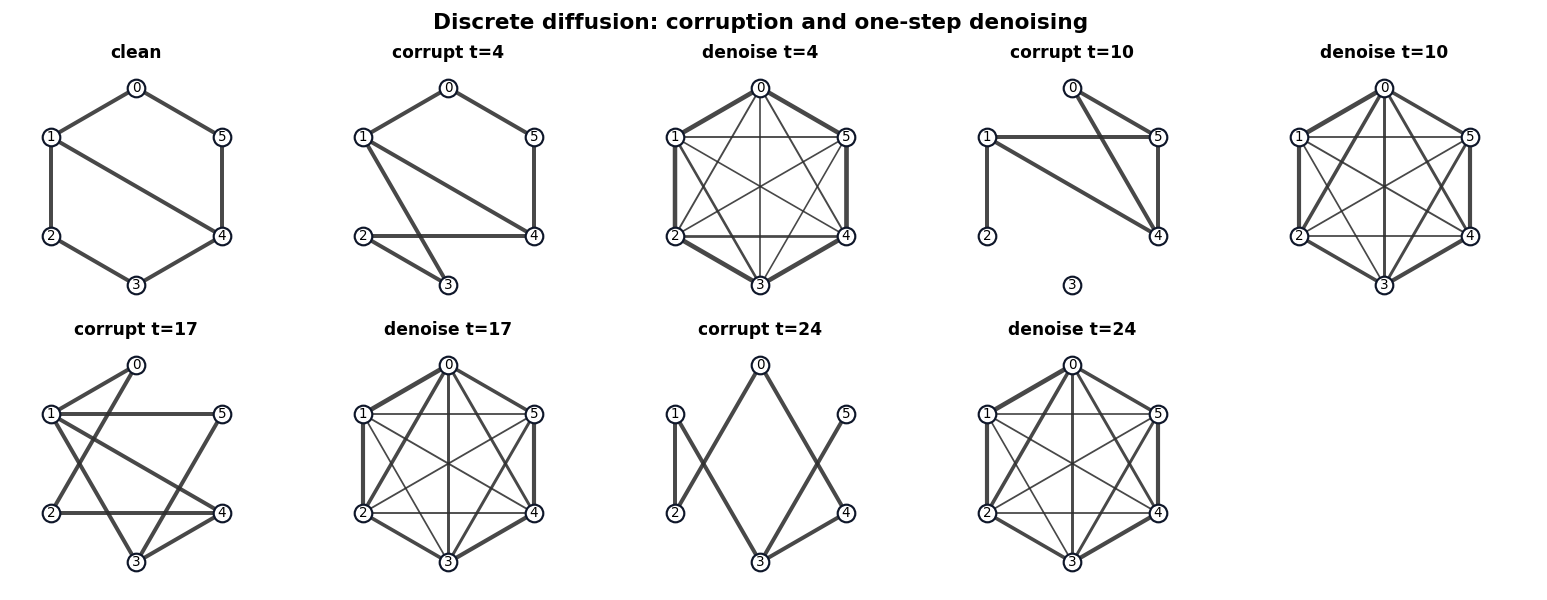

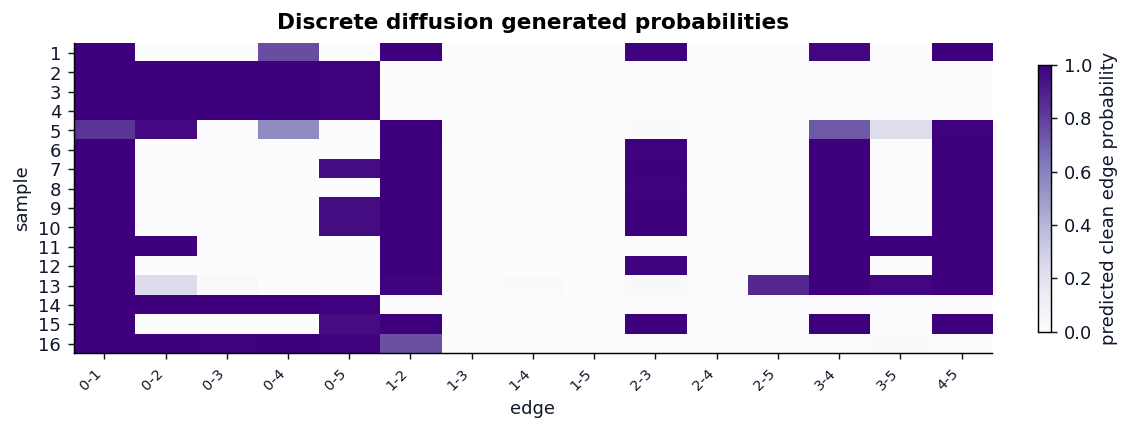

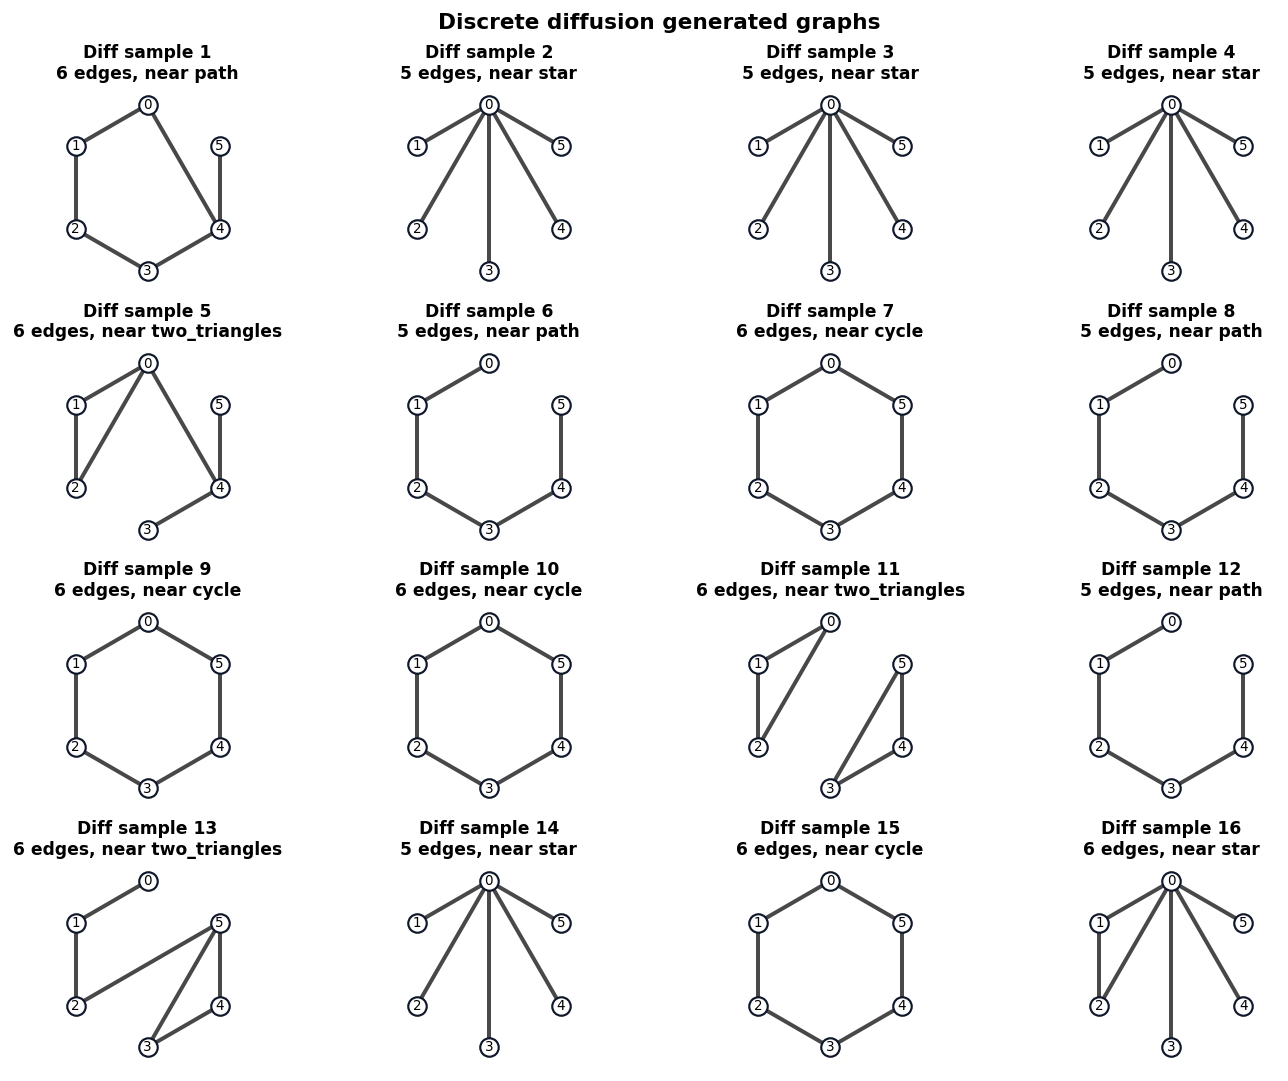

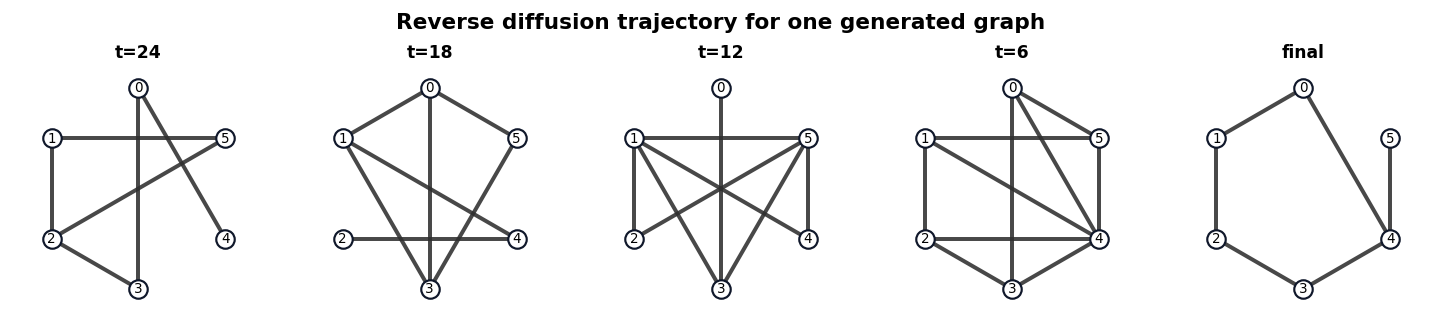

Average real edge count:                5.65
Average diffusion probability sum:      5.49
Average diffusion generated edges:      5.56
Generated edge-count range:             5 to 6
Nearest template counts:
  cycle               : 4
  star                : 5
  path                : 4
  two_triangles       : 3
Average Hamming distance to nearest template: 0.38


In [19]:

# Check: corrupt a real graph heavily, then denoise it.
denoiser.eval()
idx = np.where(y_graph == 0)[0][0]
x0 = torch.tensor(X_graph[idx:idx + 1], dtype=torch.float32, device=device)
check_steps = [0, 4, 10, 17, 24]

visuals = [vec_to_adj(x0.cpu().numpy()[0])]
titles = ["clean"]
with torch.no_grad():
    for t_value in check_steps[1:]:
        t = torch.tensor([t_value], device=device)
        xt = corrupt_edges(x0, t)
        pred_prob = torch.sigmoid(denoiser(xt, t))
        visuals.append(vec_to_adj(xt.cpu().numpy()[0]))
        titles.append(f"corrupt t={t_value}")
        visuals.append(vec_to_adj(pred_prob.cpu().numpy()[0]))
        titles.append(f"denoise t={t_value}")

plot_graph_grid(
    visuals,
    titles=titles,
    cols=5,
    figsize=(12.0, 4.5),
    node_size=0.10,
    title="Discrete diffusion: corruption and one-step denoising",
    cmap="magma",
)

# Generate new graphs by running the learned reverse process from random edges.
diff_hard, diff_probs, diff_trace = reverse_diffuse_edges(
    denoiser,
    n_samples=16,
    threshold=True,
    trace_steps=[T_disc, 18, 12, 6, 0],
    seed=2028,
)

template_vectors = np.stack([adj_to_vec(base_graph(kind)) for kind in kinds])
template_distances = np.abs(diff_hard[:, None, :] - template_vectors[None, :, :]).sum(axis=2)
nearest_template = template_distances.argmin(axis=1)
nearest_distance = template_distances.min(axis=1)

fig, ax = plt.subplots(figsize=(8.6, 3.2), constrained_layout=True)
im = ax.imshow(diff_probs, aspect="auto", cmap="Purples", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="predicted clean edge probability", shrink=0.86)
ax.set_xticks(range(N_EDGES))
ax.set_xticklabels(EDGE_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(diff_probs.shape[0]))
ax.set_yticklabels([str(i + 1) for i in range(diff_probs.shape[0])])
finish_axis(ax, "Discrete diffusion generated probabilities", "edge", "sample", grid=False)
plt.show()

diff_graphs = [vec_to_adj(diff_hard[i]) for i in range(len(diff_hard))]
diff_titles = [
    f"Diff sample {i + 1}\n{int(diff_hard[i].sum())} edges, near {kinds[nearest_template[i]]}"
    for i in range(len(diff_hard))
]
plot_graph_grid(diff_graphs, titles=diff_titles, cols=4, figsize=(10.5, 8.2), title="Discrete diffusion generated graphs")

trace_graphs = [vec_to_adj(diff_trace[t][0]) for t in [T_disc, 18, 12, 6, 0]]
trace_titles = [f"t={t}" if t > 0 else "final" for t in [T_disc, 18, 12, 6, 0]]
plot_graph_grid(trace_graphs, titles=trace_titles, cols=5, figsize=(11.2, 2.4), title="Reverse diffusion trajectory for one generated graph")

print("Average real edge count:               ", X_graph.sum(axis=1).mean().round(2))
print("Average diffusion probability sum:     ", diff_probs.sum(axis=1).mean().round(2))
print("Average diffusion generated edges:     ", diff_hard.sum(axis=1).mean().round(2))
print("Generated edge-count range:            ", int(diff_hard.sum(axis=1).min()), "to", int(diff_hard.sum(axis=1).max()))
print("Nearest template counts:")
for kind, count in zip(kinds, np.bincount(nearest_template, minlength=len(kinds))):
    print(f"  {kind:20s}: {count}")
print("Average Hamming distance to nearest template:", nearest_distance.mean().round(2))



### Part 6.2 — Conditional topology-only diffusion

The conditional version gives the denoiser the requested graph family:

$$p_\theta(x_0 \mid x_t, t, y).$$

Generation starts from random binary edges, then runs the same reverse denoising loop while holding the requested label fixed. As with conditional VAE and GAN, each row below requests one graph type.


epoch 100 | conditional denoising BCE 0.165
epoch 200 | conditional denoising BCE 0.162
epoch 300 | conditional denoising BCE 0.157
epoch 400 | conditional denoising BCE 0.156
epoch 500 | conditional denoising BCE 0.155
epoch 600 | conditional denoising BCE 0.155
epoch 700 | conditional denoising BCE 0.153


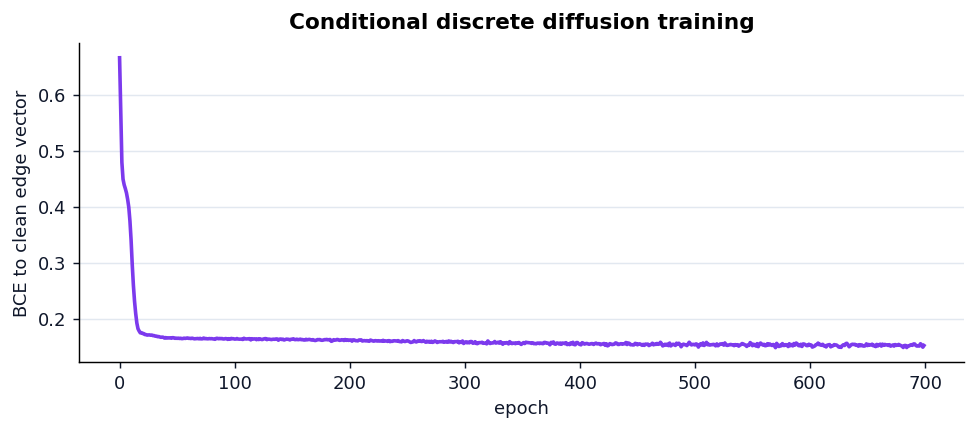

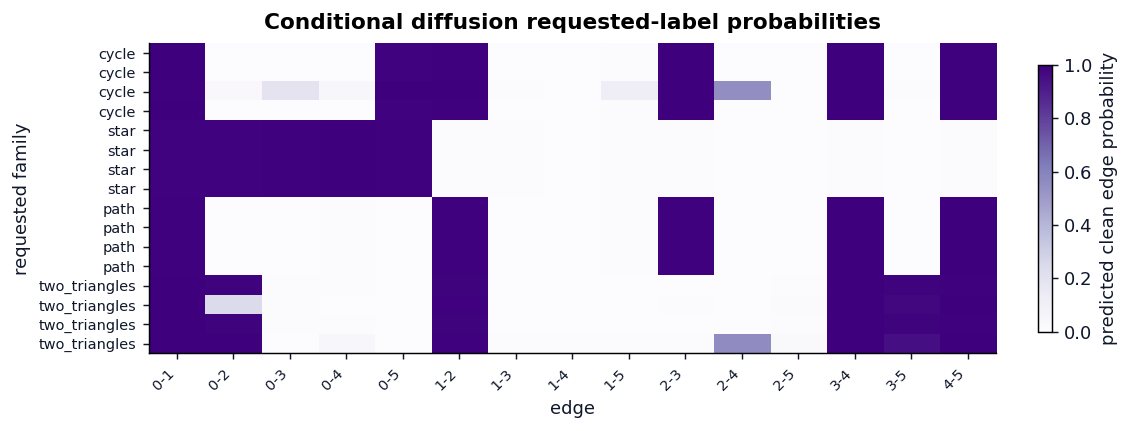

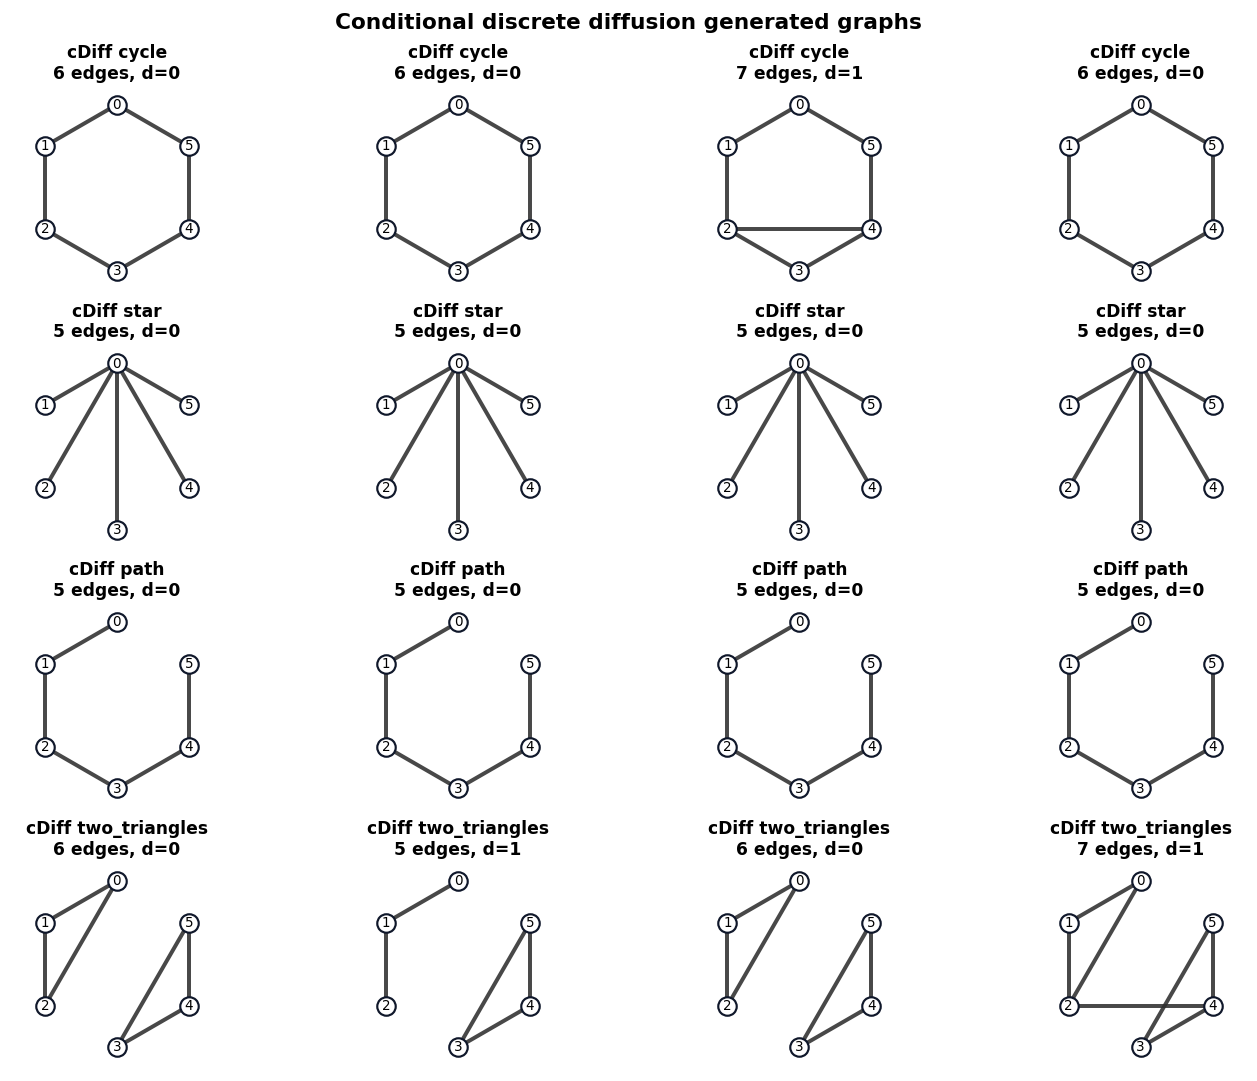

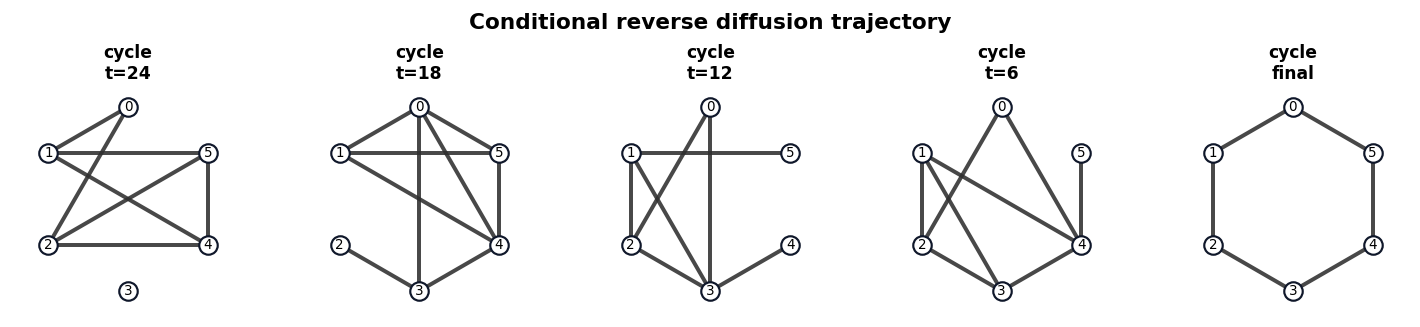

Conditional diffusion requested-template diagnostics:
  cycle               : avg edges 6.25, avg Hamming distance 0.25
  star                : avg edges 5.00, avg Hamming distance 0.00
  path                : avg edges 5.00, avg Hamming distance 0.00
  two_triangles       : avg edges 6.00, avg Hamming distance 0.50


In [20]:

class ConditionalEdgeDenoiser(nn.Module):
    def __init__(self, n_edges=N_EDGES, hidden=128, t_dim=24, n_classes=4):
        super().__init__()
        self.n_classes = n_classes
        self.t_embed = nn.Embedding(T_disc + 1, t_dim)
        self.net = nn.Sequential(
            nn.Linear(n_edges + t_dim + n_classes, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, n_edges),
        )

    def forward(self, xt, t, labels):
        y = one_hot(labels, self.n_classes).to(xt.device)
        h = torch.cat([xt, self.t_embed(t), y], dim=1)
        return self.net(h)


cond_denoiser = ConditionalEdgeDenoiser(n_classes=len(kinds)).to(device)
opt_cond_den = torch.optim.Adam(cond_denoiser.parameters(), lr=1e-3)
cond_diff_dl = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=128, shuffle=True)
cond_diff_losses = []

for epoch in range(1, 701):
    epoch_loss = 0.0
    for x0, labels in cond_diff_dl:
        x0 = x0.to(device)
        labels = labels.to(device)
        B = x0.size(0)
        t = torch.randint(1, T_disc + 1, (B,), device=device)
        xt = corrupt_edges(x0, t)
        logits = cond_denoiser(xt, t, labels)
        loss = F.binary_cross_entropy_with_logits(logits, x0)
        opt_cond_den.zero_grad()
        loss.backward()
        opt_cond_den.step()
        epoch_loss += loss.item() * B
    cond_diff_losses.append(epoch_loss / len(cond_diff_dl.dataset))
    if epoch % 100 == 0:
        print(f"epoch {epoch:3d} | conditional denoising BCE {cond_diff_losses[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7.4, 3.2), constrained_layout=True)
ax.plot(cond_diff_losses, color=PALETTE["purple"], linewidth=2)
finish_axis(ax, "Conditional discrete diffusion training", "epoch", "BCE to clean edge vector")
plt.show()

requested_labels = torch.arange(len(kinds), device=device).repeat_interleave(4)
cond_diff_hard, cond_diff_probs, cond_diff_trace = reverse_diffuse_edges(
    cond_denoiser,
    n_samples=len(requested_labels),
    labels=requested_labels,
    conditional=True,
    threshold=True,
    trace_steps=[T_disc, 18, 12, 6, 0],
    seed=2029,
)
requested_labels_np = requested_labels.cpu().numpy()
template_vectors = np.stack([adj_to_vec(base_graph(kind)) for kind in kinds])
requested_distance = np.abs(cond_diff_hard - template_vectors[requested_labels_np]).sum(axis=1)

fig, ax = plt.subplots(figsize=(8.6, 3.2), constrained_layout=True)
im = ax.imshow(cond_diff_probs, aspect="auto", cmap="Purples", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="predicted clean edge probability", shrink=0.86)
ax.set_xticks(range(N_EDGES))
ax.set_xticklabels(EDGE_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(requested_labels_np)))
ax.set_yticklabels([kinds[label] for label in requested_labels_np], fontsize=8)
finish_axis(ax, "Conditional diffusion requested-label probabilities", "edge", "requested family", grid=False)
plt.show()

cond_diff_graphs = [vec_to_adj(cond_diff_hard[i]) for i in range(len(cond_diff_hard))]
cond_diff_titles = [
    f"cDiff {kinds[requested_labels_np[i]]}\n{int(cond_diff_hard[i].sum())} edges, d={int(requested_distance[i])}"
    for i in range(len(cond_diff_hard))
]
plot_graph_grid(
    cond_diff_graphs,
    titles=cond_diff_titles,
    cols=4,
    figsize=(10.5, 8.2),
    title="Conditional discrete diffusion generated graphs",
)

trace_graphs = [vec_to_adj(cond_diff_trace[t][0]) for t in [T_disc, 18, 12, 6, 0]]
trace_titles = [f"{kinds[requested_labels_np[0]]}\nt={t}" if t > 0 else f"{kinds[requested_labels_np[0]]}\nfinal" for t in [T_disc, 18, 12, 6, 0]]
plot_graph_grid(trace_graphs, titles=trace_titles, cols=5, figsize=(11.2, 2.4), title="Conditional reverse diffusion trajectory")

print("Conditional diffusion requested-template diagnostics:")
for label, kind in enumerate(kinds):
    mask = requested_labels_np == label
    print(
        f"  {kind:20s}: avg edges {cond_diff_hard[mask].sum(axis=1).mean():.2f}, "
        f"avg Hamming distance {requested_distance[mask].mean():.2f}"
    )


---
## Part 7 - What the fixed-order topology models still cannot do

The topology-only models above were intentionally simplified. They assumed:

$$x \in \{0,1\}^{\binom{n}{2}}$$

with a fixed node count $n=6$, binary edges, and a fixed node order. That makes the VAE/GAN/diffusion mechanics easy to teach, but it hides three core graph-generation problems.

| Challenge | What breaks in the simple model | What we need to add |
|---|---|---|
| Size of the graph | A fixed edge vector only works for one node count. | A graph-size variable, node-existence mask, or STOP action. |
| Feature and topology | Binary edges ignore node labels and edge labels. | Joint categorical predictions for node features $X_i$ and edge features $E_{ij}$. |
| Permutation invariance | Relabeling nodes changes the vector even though the graph is the same. | Invariant encoders/discriminators and permutation-aware decoder losses. |

A realistic graph generator therefore works with something closer to

$$G=(M,X,E),$$

where $M$ says which padded node slots are real, $X$ stores node categories, and $E$ stores edge categories including a special `none` edge type.

The next cells are a bridge from the clean lecture models to realistic graph generators. The goal is not to train a large new model yet; the goal is to make the representation, losses, and symmetry requirements explicit.


---
## Part 8 - Challenge 1: variable graph size

A fixed vector such as

$$x=(A_{01},A_{02},\dots,A_{n-2,n-1})$$

only works when every graph has the same number of nodes. For variable-size graphs, a common tutorial-friendly representation is:

$$M_i \in \{0,1\} \quad \text{node exists mask},$$

$$X_i \in \{0,\dots,C_X-1\} \quad \text{node feature category},$$

$$E_{ij} \in \{0,\dots,C_E-1\} \quad \text{edge feature category}.$$

We choose a maximum size $N_{\max}$, pad smaller graphs, and carry masks so losses and plots ignore padded nodes. The padded tensor has a fixed shape, but the mask recovers the variable-size graph.

For generation, the decoder can produce:

| Decoder head | Shape | Meaning |
|---|---:|---|
| Node existence | `(batch, N_max)` | Is padded slot $i$ active? |
| Node category | `(batch, N_max, C_X)` | What type is active node $i$? |
| Edge category | `(batch, N_max, N_max, C_E)` | What type is pair $(i,j)$? |

Two small but important conventions:

1. `E_ij = 0` means **no edge**, so sparsity is learned as an edge category.
2. For undirected graphs, edge logits should be symmetric and diagonal edges should be ignored or forced to `none`.


node type tensor: (5, 8) = (batch, N_max)
edge type tensor: (5, 8, 8) = (batch, N_max, N_max)
node mask tensor: (5, 8) = (batch, N_max)
active node counts: [4, 5, 6, 7, 8]


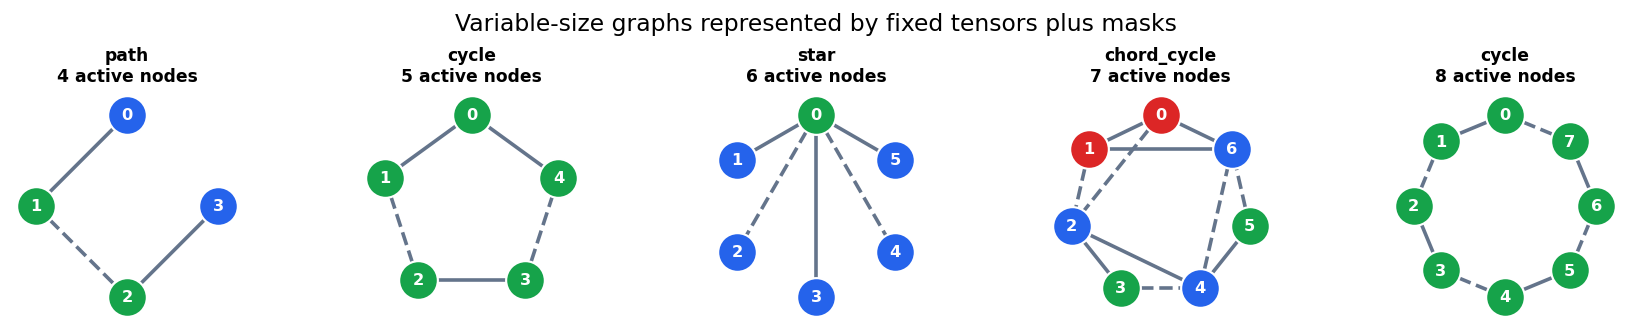

In [51]:
VAR_MAX_NODES = 8
VAR_NODE_TYPES = ["red", "blue", "green"]
VAR_EDGE_TYPES = ["none", "solid", "dashed"]
VAR_NO_EDGE = 0

VAR_COLORS = {
    0: PALETTE["red"],
    1: PALETTE["blue"],
    2: PALETTE["green"],
}
VAR_EDGE_STYLE = {
    1: (2.0, "-"),
    2: (2.0, "--"),
}


def variable_base_graph(kind, n_nodes):
    A = np.zeros((n_nodes, n_nodes), dtype=np.int64)
    if kind == "path":
        edges = [(i, i + 1) for i in range(n_nodes - 1)]
    elif kind == "cycle":
        edges = [(i, (i + 1) % n_nodes) for i in range(n_nodes)]
    elif kind == "star":
        edges = [(0, i) for i in range(1, n_nodes)]
    elif kind == "chord_cycle":
        edges = [(i, (i + 1) % n_nodes) for i in range(n_nodes)]
        edges += [(i, (i + 2) % n_nodes) for i in range(0, n_nodes, 2)]
    else:
        raise ValueError(f"unknown kind: {kind}")

    for edge_idx, (i, j) in enumerate(edges):
        edge_type = 1 + (edge_idx % 2)  # alternate solid and dashed categorical edge features
        A[i, j] = edge_type
        A[j, i] = edge_type

    # Toy node features. Real data would provide atom types, user types, token labels, etc.
    degrees = (A > 0).sum(axis=1)
    node_types = (degrees % len(VAR_NODE_TYPES)).astype(np.int64)
    return node_types, A


def pad_variable_graph(node_types, edge_types, max_nodes=VAR_MAX_NODES):
    n_nodes = len(node_types)
    node_mask = np.zeros(max_nodes, dtype=np.float32)
    padded_nodes = np.zeros(max_nodes, dtype=np.int64)
    padded_edges = np.zeros((max_nodes, max_nodes), dtype=np.int64)

    node_mask[:n_nodes] = 1.0
    padded_nodes[:n_nodes] = node_types
    padded_edges[:n_nodes, :n_nodes] = edge_types
    return padded_nodes, padded_edges, node_mask


def plot_variable_graph_grid(node_type_list, edge_type_list, node_masks, titles=None, cols=4, title=None):
    n_graphs = len(node_type_list)
    rows = math.ceil(n_graphs / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.65 * cols, 2.45 * rows), squeeze=False, constrained_layout=True)

    for idx, ax in enumerate(axes.flat):
        ax.axis("off")
        ax.set_aspect("equal")
        if idx >= n_graphs:
            continue

        mask = np.asarray(node_masks[idx]).astype(bool)
        active = np.where(mask)[0]
        n_active = len(active)
        angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, max(n_active, 1), endpoint=False)
        pos = {node: np.array([np.cos(angle), np.sin(angle)]) for node, angle in zip(active, angles)}
        edge_types = np.asarray(edge_type_list[idx])
        node_types = np.asarray(node_type_list[idx])

        for local_i, i in enumerate(active):
            for j in active[local_i + 1:]:
                edge_type = int(edge_types[i, j])
                if edge_type == VAR_NO_EDGE:
                    continue
                width, style = VAR_EDGE_STYLE[edge_type]
                xy_i, xy_j = pos[i], pos[j]
                ax.plot([xy_i[0], xy_j[0]], [xy_i[1], xy_j[1]], color="#64748b", lw=width, ls=style, zorder=1)

        for node in active:
            xy = pos[node]
            node_type = int(node_types[node])
            ax.scatter([xy[0]], [xy[1]], s=460, color=VAR_COLORS[node_type], edgecolor="white", linewidth=1.2, zorder=3)
            ax.text(xy[0], xy[1], str(node), ha="center", va="center", color="white", fontweight="bold", fontsize=9, zorder=4)

        if titles is not None:
            ax.set_title(titles[idx], fontsize=9.5)
        ax.set_xlim(-1.25, 1.25)
        ax.set_ylim(-1.25, 1.25)

    if title:
        fig.suptitle(title, fontsize=13)
    plt.show()


variable_specs = [
    ("path", 4),
    ("cycle", 5),
    ("star", 6),
    ("chord_cycle", 7),
    ("cycle", 8),
]

var_nodes, var_edges, var_masks, var_titles = [], [], [], []
for kind, n_nodes in variable_specs:
    node_types, edge_types = variable_base_graph(kind, n_nodes)
    padded_nodes, padded_edges, node_mask = pad_variable_graph(node_types, edge_types)
    var_nodes.append(padded_nodes)
    var_edges.append(padded_edges)
    var_masks.append(node_mask)
    var_titles.append(f"{kind}\n{n_nodes} active nodes")

var_nodes = np.stack(var_nodes)
var_edges = np.stack(var_edges)
var_masks = np.stack(var_masks)

print("node type tensor:", var_nodes.shape, "= (batch, N_max)")
print("edge type tensor:", var_edges.shape, "= (batch, N_max, N_max)")
print("node mask tensor:", var_masks.shape, "= (batch, N_max)")
print("active node counts:", var_masks.sum(axis=1).astype(int).tolist())

plot_variable_graph_grid(
    var_nodes,
    var_edges,
    var_masks,
    titles=var_titles,
    cols=5,
    title="Variable-size graphs represented by fixed tensors plus masks",
)


---
## Part 9 - Challenge 2: node features plus topology

For attributed graphs, the object is not just adjacency. It is the masked attributed graph

$$G=(M,X,E),$$

where $X_i$ is a node category and $E_{ij}$ is an edge category. The category `none` is included as an edge type, so every possible active pair has a categorical label.

A masked decoder can be trained with three reconstruction losses:

$$\mathcal{L}_{\text{exists}}=\operatorname{BCEWithLogits}(\hat M,M),$$

$$\mathcal{L}_{\text{node}}=\sum_{i:M_i=1}\operatorname{CE}(\hat X_i,X_i),$$

$$\mathcal{L}_{\text{edge}}=\sum_{i<j:M_iM_j=1}\operatorname{CE}(\hat E_{ij},E_{ij}).$$

The important detail is masking. Padded nodes should not contribute to feature losses, and edges touching padded nodes should not contribute to edge losses. No-edge pairs between real nodes **do** contribute, because the model must learn when an active pair should remain disconnected.


decoder node-existence logits: (5, 8)
decoder node-feature logits: (5, 8, 3)
decoder edge-feature logits: (5, 8, 8, 3)
valid active nodes in node CE: 30
valid active unordered node pairs in edge CE: 80
node existence BCE: 0.061
node feature CE:    0.198
edge feature CE:    0.168
total masked loss:  0.427


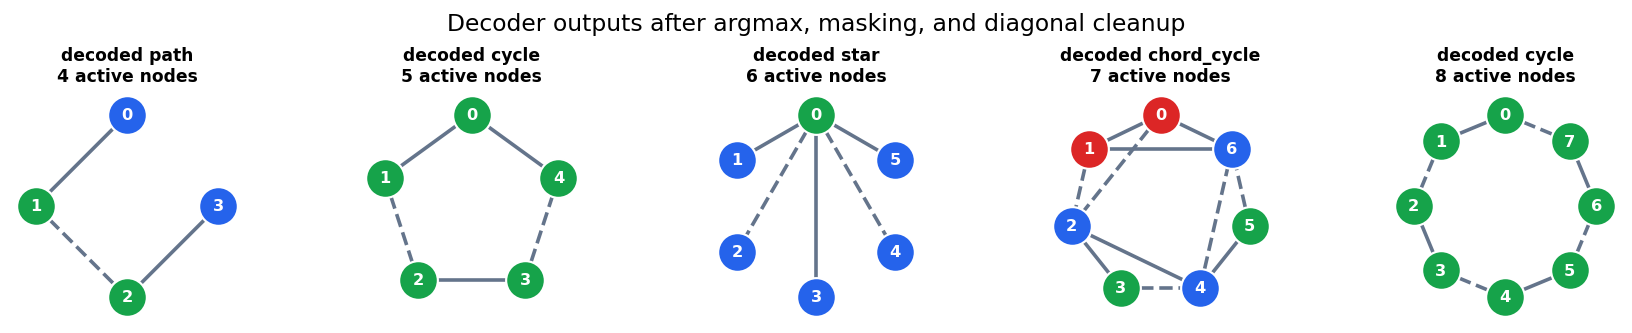

In [52]:
B = var_nodes.shape[0]
N = VAR_MAX_NODES
C_node = len(VAR_NODE_TYPES)
C_edge = len(VAR_EDGE_TYPES)

node_targets = torch.tensor(var_nodes, dtype=torch.long, device=device)
edge_targets = torch.tensor(var_edges, dtype=torch.long, device=device)
node_masks = torch.tensor(var_masks, dtype=torch.float32, device=device)
edge_pair_mask = (node_masks[:, :, None] * node_masks[:, None, :]).bool()
upper_pair_mask = torch.triu(torch.ones(N, N, dtype=torch.bool, device=device), diagonal=1)
valid_edge_mask = edge_pair_mask & upper_pair_mask[None, :, :]


def make_target_biased_logits(targets, n_classes, strength=2.5, noise=0.7):
    # Teaching stand-in for decoder logits: noisy, but biased toward the target class.
    logits = noise * torch.randn(*targets.shape, n_classes, device=targets.device)
    logits.scatter_(-1, targets[..., None], strength)
    return logits


def symmetrize_edge_logits(edge_logits):
    return 0.5 * (edge_logits + edge_logits.transpose(1, 2))


# These logits stand in for a VAE/GAN/diffusion decoder output.
# They are target-biased only so the printed losses and decoded samples are easy to read.
torch.manual_seed(7)
node_exists_logits = 3.0 * (2.0 * node_masks - 1.0) + 0.7 * torch.randn(B, N, device=device)
node_type_logits = make_target_biased_logits(node_targets, C_node)
edge_type_logits = symmetrize_edge_logits(make_target_biased_logits(edge_targets, C_edge))

node_exists_loss = F.binary_cross_entropy_with_logits(node_exists_logits, node_masks)
node_type_loss = F.cross_entropy(node_type_logits[node_masks.bool()], node_targets[node_masks.bool()])
edge_type_loss = F.cross_entropy(edge_type_logits[valid_edge_mask], edge_targets[valid_edge_mask])
masked_attributed_loss = node_exists_loss + node_type_loss + edge_type_loss

print("decoder node-existence logits:", tuple(node_exists_logits.shape))
print("decoder node-feature logits:", tuple(node_type_logits.shape))
print("decoder edge-feature logits:", tuple(edge_type_logits.shape))
print("valid active nodes in node CE:", int(node_masks.sum().item()))
print("valid active unordered node pairs in edge CE:", int(valid_edge_mask.sum().item()))
print(f"node existence BCE: {node_exists_loss.item():.3f}")
print(f"node feature CE:    {node_type_loss.item():.3f}")
print(f"edge feature CE:    {edge_type_loss.item():.3f}")
print(f"total masked loss:  {masked_attributed_loss.item():.3f}")

# Generation-time postprocessing: logits -> mask, node labels, edge labels.
with torch.no_grad():
    decoded_masks = (torch.sigmoid(node_exists_logits) > 0.5).float()
    empty_graphs = decoded_masks.sum(dim=1) == 0
    decoded_masks[empty_graphs, 0] = 1.0

    decoded_nodes = node_type_logits.argmax(dim=-1)
    decoded_edges = edge_type_logits.argmax(dim=-1)

    diagonal = torch.eye(N, dtype=torch.bool, device=device)
    active_pair_mask = (decoded_masks[:, :, None] * decoded_masks[:, None, :]).bool()
    decoded_edges[:, diagonal] = VAR_NO_EDGE
    decoded_edges = decoded_edges.masked_fill(~active_pair_mask, VAR_NO_EDGE)

plot_variable_graph_grid(
    decoded_nodes.cpu().numpy(),
    decoded_edges.cpu().numpy(),
    decoded_masks.cpu().numpy(),
    titles=[f"decoded {title}" for title in var_titles],
    cols=5,
    title="Decoder outputs after argmax, masking, and diagonal cleanup",
)


---
## Part 10 - Challenge 3: permutation invariance

A graph does not come with a unique node order. If we relabel the nodes with a permutation matrix $P$, then

$$X' = P X, \qquad E' = P E P^\top.$$

The adjacency tensor changes, but the graph identity has not changed.

The fixed-vector models above used an edge order like

$$(0,1),(0,2),(0,3),\dots$$

That means a relabeled copy of the same graph can look like a different training example. This is the **permutation invariance** problem.

Common solutions:

| Strategy | How it helps | Tradeoff |
|---|---|---|
| Canonical ordering | Convert each graph to a deterministic node order before vectorizing. | Simple when a strong canonicalizer exists; brittle otherwise. |
| GNN encoder + pooling | Message passing is permutation equivariant; sum/mean pooling is invariant. | Fixes encoders and discriminators, but decoder alignment still matters. |
| Permutation-aware reconstruction loss | Match generated nodes to target nodes before computing loss. | Correct for small graphs, but expensive for large graphs. |
| Autoregressive construction | Generate graph as a sequence of actions with a chosen ordering. | Needs an ordering policy; may still need canonicalization. |
| Equivariant diffusion | Noise and denoise node/edge tensors with permutation-equivariant networks. | More complex, but closest to the graph symmetry. |

The code below shows two separate facts:

1. A fixed-order reconstruction loss can punish a perfect relabeled graph.
2. A GNN with graph-level pooling gives the same embedding after relabeling.


Fixed-order edge-vector mismatch: 8
Fixed-order node-label mismatch: 5
Best permutation-aware attributed mismatch: 0
Sorted degree sequence original: [2, 2, 2, 2, 2, 2]
Sorted degree sequence permuted: [2, 2, 2, 2, 2, 2]


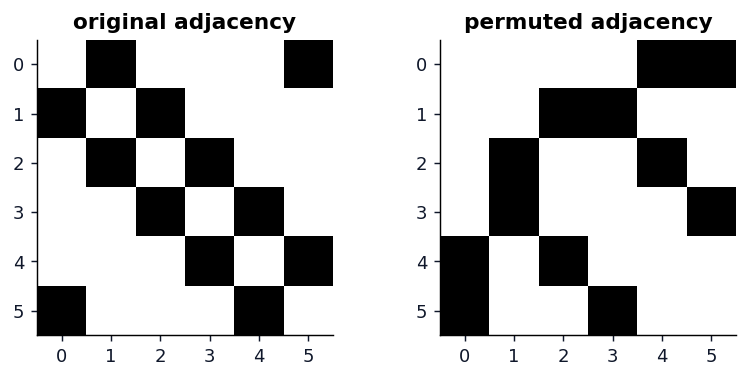

GNN sum-pooled embedding difference after permutation: 4.76837158203125e-07
The tiny numerical difference should be near 0: same graph, same invariant embedding.


In [53]:
from itertools import permutations

# Same attributed graph, two different node labelings.
A = base_graph("cycle")
node_types = np.arange(N_NODES) % 3
perm = np.array([2, 5, 0, 4, 1, 3])
A_perm = A[perm][:, perm]
node_types_perm = node_types[perm]

vec = adj_to_vec(A)
vec_perm = adj_to_vec(A_perm)
fixed_edge_mismatch = int(np.abs(vec - vec_perm).sum())
fixed_node_mismatch = int((node_types != node_types_perm).sum())


def attributed_reconstruction_mismatch(A_target, x_target, A_pred, x_pred, reorder=None):
    if reorder is not None:
        A_pred = A_pred[np.ix_(reorder, reorder)]
        x_pred = x_pred[list(reorder)]
    edge_mismatch = np.abs(adj_to_vec(A_target) - adj_to_vec(A_pred)).sum()
    node_mismatch = (x_target != x_pred).sum()
    return int(edge_mismatch + node_mismatch)


best_matching_mismatch = min(
    attributed_reconstruction_mismatch(A, node_types, A_perm, node_types_perm, reorder=p)
    for p in permutations(range(N_NODES))
)

print("Fixed-order edge-vector mismatch:", fixed_edge_mismatch)
print("Fixed-order node-label mismatch:", fixed_node_mismatch)
print("Best permutation-aware attributed mismatch:", best_matching_mismatch)
print("Sorted degree sequence original:", sorted(A.sum(axis=1).astype(int).tolist()))
print("Sorted degree sequence permuted:", sorted(A_perm.sum(axis=1).astype(int).tolist()))

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.8), constrained_layout=True)
axes[0].imshow(A, cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("original adjacency")
axes[1].imshow(A_perm, cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("permuted adjacency")
for ax in axes:
    ax.set_xticks(range(N_NODES))
    ax.set_yticks(range(N_NODES))
plt.show()


def simple_gnn_graph_embedding(A_np, node_type_np, weights):
    A_t = torch.tensor(A_np, dtype=torch.float32)
    X_t = F.one_hot(torch.tensor(node_type_np, dtype=torch.long), num_classes=3).float()
    W_self, W_neigh = weights
    H = torch.relu(X_t @ W_self + A_t @ X_t @ W_neigh)
    return H.sum(dim=0)  # invariant graph pooling


torch.manual_seed(11)
weights = (
    torch.randn(3, 5),
    torch.randn(3, 5),
)
emb = simple_gnn_graph_embedding(A, node_types, weights)
emb_perm = simple_gnn_graph_embedding(A_perm, node_types_perm, weights)
print("GNN sum-pooled embedding difference after permutation:", torch.norm(emb - emb_perm).item())
print("The tiny numerical difference should be near 0: same graph, same invariant embedding.")


### Part 10.1 - Failure case: the supervised GraphVAE sees relabeled cycles as different graphs

The GraphVAE above is the **supervised prototype version**: during training, it is explicitly encouraged to map cycles, stars, paths, and two-triangle graphs into different latent regions using the classification loss

$$\mathcal{L}_{\text{sup}}=\mathrm{CE}(s(A), y).$$

So if any fixed-order model should have a clean latent space, it is this one. But it was still trained on a **fixed edge-vector order**. If we take the same cycle graph and simply relabel its nodes, the graph is isomorphic, but the vector entries move to different coordinates.

A permutation-invariant graph autoencoder should map all relabeled versions of the cycle to the same graph-level representation. The supervised fixed-order GraphVAE does not know that matching step.

This demo applies several different node permutations to the same cycle and checks two symptoms:

1. **Supervised latent failure:** the same cycle moves to different supervised prototype regions, sometimes classified as `star` or `path`.
2. **Decoding failure:** the decoded graph changes according to where that latent point landed.


Same cycle graph under different node permutations, using the supervised fixed-order GraphVAE:
idx | fixed-vector distance | supervised prediction | confidence | fixed recon error | best-match error
  0 |                     0 | cycle                 |       0.98 |                 0 |                0
  1 |                     6 | cycle                 |       0.66 |                 3 |                3
  2 |                     6 | star                  |       0.81 |                 3 |                1
  3 |                    10 | star                  |       0.98 |                 8 |                4
  4 |                     6 | path                  |       0.62 |                 4 |                4
  5 |                     6 | two_triangles         |       0.97 |                 2 |                2

Average latent distance from identity permutation: 4.680
Distance from each permuted-cycle latent point to family centers:
  perm 0: nearest center cycle | cycle=1.39, star=3.9

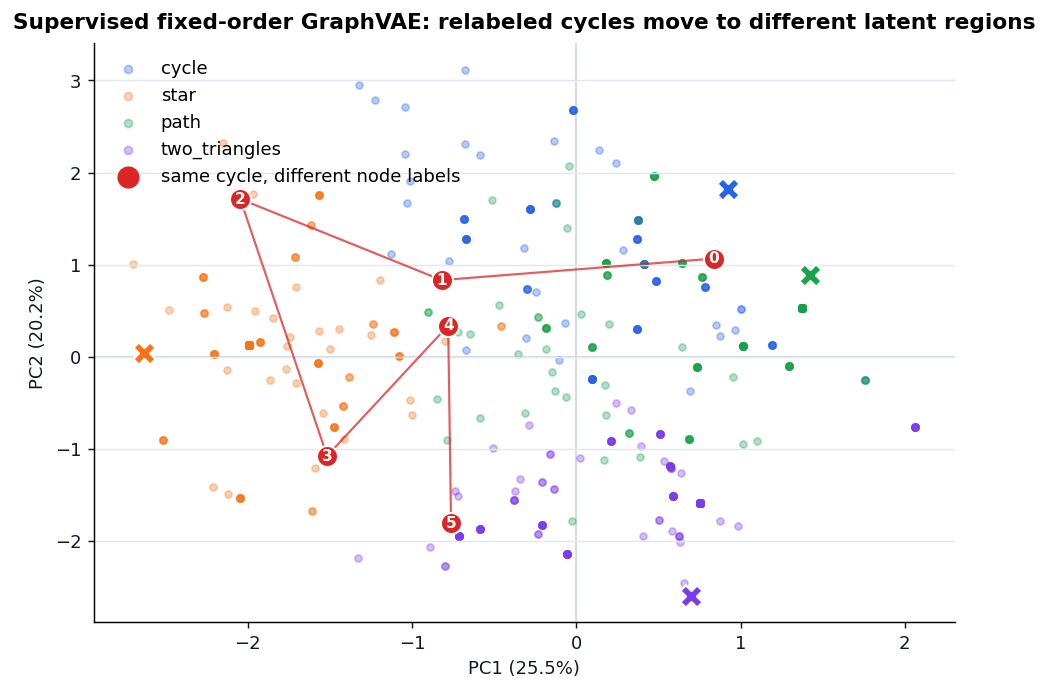

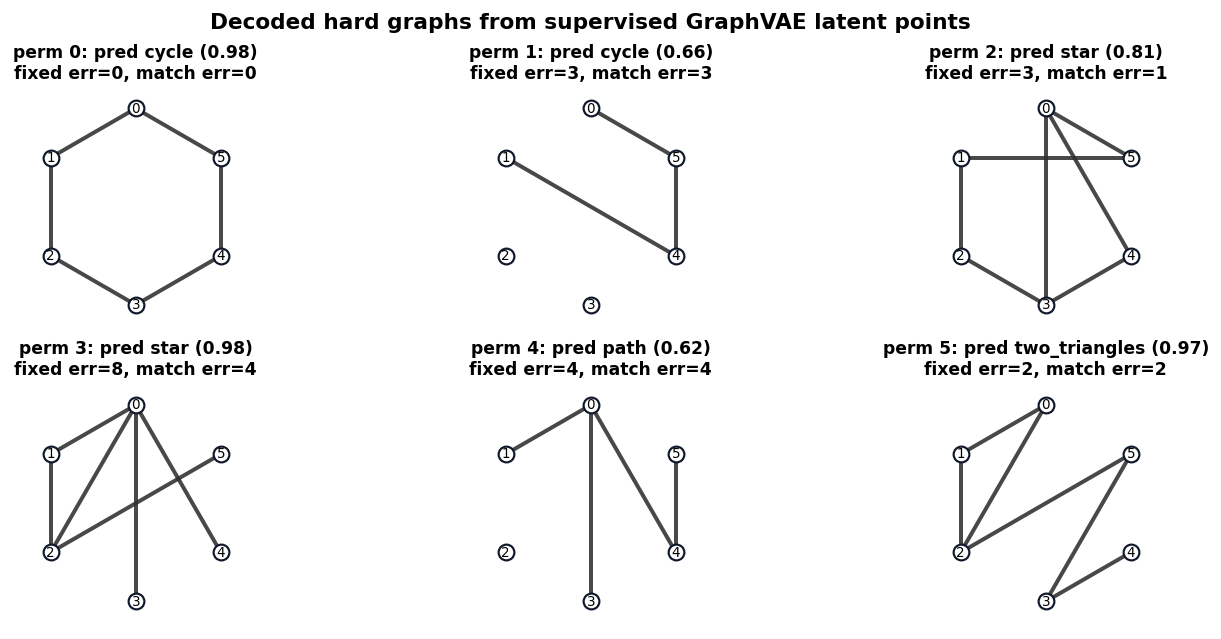

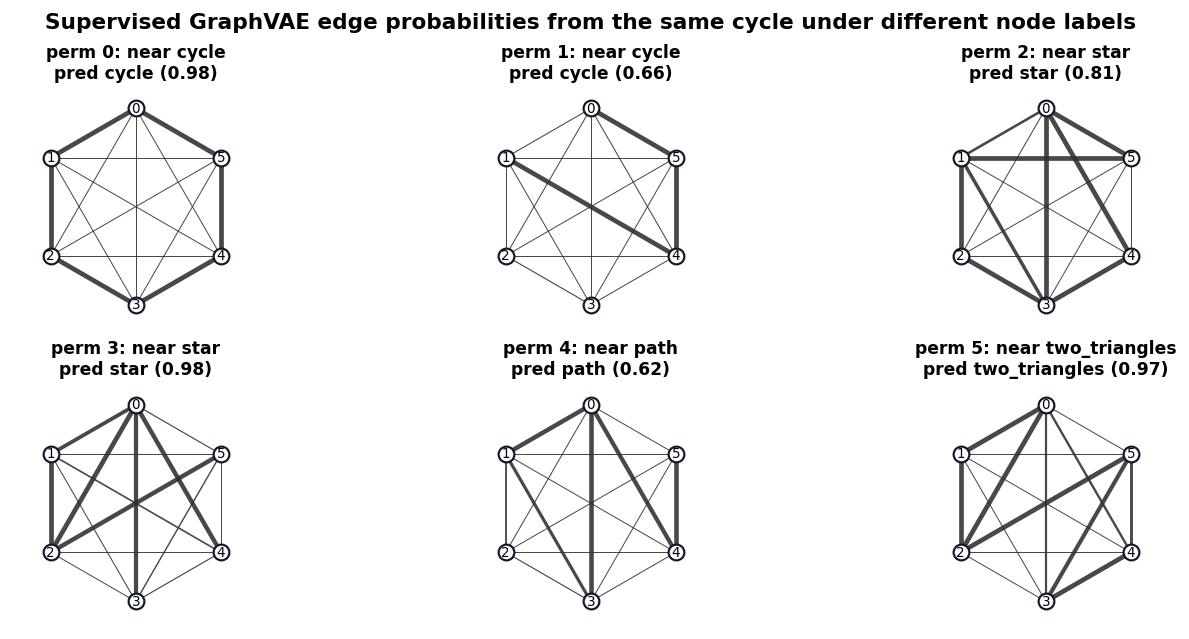

(<Figure size 1365x624 with 6 Axes>,
 array([[<Axes: title={'center': 'perm 0: near cycle\npred cycle (0.98)'}>,
         <Axes: title={'center': 'perm 1: near cycle\npred cycle (0.66)'}>,
         <Axes: title={'center': 'perm 2: near star\npred star (0.81)'}>],
        [<Axes: title={'center': 'perm 3: near star\npred star (0.98)'}>,
         <Axes: title={'center': 'perm 4: near path\npred path (0.62)'}>,
         <Axes: title={'center': 'perm 5: near two_triangles\npred two_triangles (0.97)'}>]],
       dtype=object))

In [72]:
from itertools import permutations


def deterministic_vae_reconstruct(model, x_vec):
    """Use mu instead of sampling z so the reconstruction comparison is stable."""
    model.eval()
    x = torch.tensor(x_vec[None, :], dtype=torch.float32, device=device)
    with torch.no_grad():
        mu, _ = model.encode(x)
        probs = torch.sigmoid(model.decode_logits(mu)).cpu().numpy()[0]
        hard = (probs >= 0.5).astype(np.float32)
        class_logits = model.latent_class_logits(mu)
        class_probs = F.softmax(class_logits, dim=1)
        predicted_label = int(class_logits.argmax(dim=1).item())
        predicted_confidence = float(class_probs.max(dim=1).values.item())
    return probs, hard, predicted_label, predicted_confidence, mu.cpu().numpy()[0]


def best_permutation_edge_distance(A_target, A_pred):
    """Brute-force graph matching distance for N=6; okay for a teaching demo."""
    best = N_EDGES + 1
    best_perm = None
    for p in permutations(range(N_NODES)):
        A_reordered = A_pred[np.ix_(p, p)]
        dist = int(np.abs(adj_to_vec(A_target) - adj_to_vec(A_reordered)).sum())
        if dist < best:
            best = dist
            best_perm = p
    return best, best_perm


def make_nontrivial_cycle_permutations(A, n_permutations=6, seed=5):
    """Identity plus permutations that actually change the fixed edge vector."""
    rng = np.random.default_rng(seed)
    base_vec = adj_to_vec(A)
    perms = [np.arange(N_NODES)]
    seen = {tuple(perms[0])}
    while len(perms) < n_permutations:
        p = rng.permutation(N_NODES)
        key = tuple(p.tolist())
        if key in seen:
            continue
        if np.abs(base_vec - adj_to_vec(A[np.ix_(p, p)])).sum() == 0:
            continue
        perms.append(p)
        seen.add(key)
    return perms


# One cycle graph, many relabelings.
A_cycle = base_graph("cycle")
permutation_list = make_nontrivial_cycle_permutations(A_cycle, n_permutations=6)
cycle_variants = [A_cycle[np.ix_(p, p)] for p in permutation_list]
cycle_vectors = [adj_to_vec(A) for A in cycle_variants]

variant_probs, variant_hard, variant_labels, variant_confidences, variant_mu = [], [], [], [], []
fixed_errors, best_match_errors, vector_distances = [], [], []
for A_variant, x_variant in zip(cycle_variants, cycle_vectors):
    probs, hard, label, confidence, mu = deterministic_vae_reconstruct(vae, x_variant)
    variant_probs.append(probs)
    variant_hard.append(hard)
    variant_labels.append(label)
    variant_confidences.append(confidence)
    variant_mu.append(mu)
    fixed_errors.append(int(np.abs(hard - x_variant).sum()))
    best_match_errors.append(best_permutation_edge_distance(A_variant, vec_to_adj(hard))[0])
    vector_distances.append(int(np.abs(cycle_vectors[0] - x_variant).sum()))

variant_mu = np.stack(variant_mu)
variant_labels = np.array(variant_labels)
variant_confidences = np.array(variant_confidences)
fixed_errors = np.array(fixed_errors)
best_match_errors = np.array(best_match_errors)
vector_distances = np.array(vector_distances)

print("Same cycle graph under different node permutations, using the supervised fixed-order GraphVAE:")
print("idx | fixed-vector distance | supervised prediction | confidence | fixed recon error | best-match error")
for idx in range(len(permutation_list)):
    print(
        f" {idx:>2d} | {vector_distances[idx]:>21d} | {kinds[variant_labels[idx]]:<21s} | "
        f"{variant_confidences[idx]:>10.2f} | {fixed_errors[idx]:>17d} | {best_match_errors[idx]:>16d}"
    )
print()
print(f"Average latent distance from identity permutation: {np.linalg.norm(variant_mu - variant_mu[:1], axis=1)[1:].mean():.3f}")

# Latent-space view: where did the encoder send each relabeling?
vae.eval()
with torch.no_grad():
    mu_all, _ = vae.encode(X_tensor.to(device))
latent = mu_all.cpu().numpy()
class_centers = vae.class_centers.detach().cpu().numpy()

latent_mean = latent.mean(axis=0, keepdims=True)
latent_centered = latent - latent_mean
_, singular_values, vh = np.linalg.svd(latent_centered, full_matrices=False)
latent_2d = latent_centered @ vh[:2].T
center_2d = (class_centers - latent_mean) @ vh[:2].T
variant_2d = (variant_mu - latent_mean) @ vh[:2].T
explained = singular_values**2 / (len(latent_centered) - 1)
explained_ratio = explained / explained.sum()

center_distances = np.linalg.norm(class_centers[None, :, :] - variant_mu[:, None, :], axis=2)
print("Distance from each permuted-cycle latent point to family centers:")
for idx in range(len(permutation_list)):
    nearest = center_distances[idx].argmin()
    center_summary = ", ".join(f"{kinds[j]}={center_distances[idx, j]:.2f}" for j in range(len(kinds)))
    print(f"  perm {idx}: nearest center {kinds[nearest]} | {center_summary}")

fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["green"], PALETTE["purple"]]
for label, kind in enumerate(kinds):
    mask = y_graph == label
    ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1], s=15, alpha=0.32, label=kind, color=colors[label])
    ax.scatter(
        center_2d[label, 0],
        center_2d[label, 1],
        marker="X",
        s=155,
        color=colors[label],
        edgecolors="white",
        linewidths=1.3,
        zorder=4,
    )

ax.plot(variant_2d[:, 0], variant_2d[:, 1], color="#dc2626", linewidth=1.2, alpha=0.75, zorder=5)
ax.scatter(
    variant_2d[:, 0],
    variant_2d[:, 1],
    s=135,
    marker="o",
    color="#dc2626",
    edgecolors="white",
    linewidths=1.1,
    zorder=6,
    label="same cycle, different node labels",
)
for idx, xy in enumerate(variant_2d):
    ax.text(xy[0], xy[1], str(idx), fontsize=8.5, ha="center", va="center", color="white", fontweight="bold", zorder=7)

finish_axis(
    ax,
    "Supervised fixed-order GraphVAE: relabeled cycles move to different latent regions",
    f"PC1 ({explained_ratio[0]:.1%})",
    f"PC2 ({explained_ratio[1]:.1%})",
    grid=True,
)
ax.axhline(0, color="#cbd5e1", linewidth=0.9, zorder=0)
ax.axvline(0, color="#cbd5e1", linewidth=0.9, zorder=0)
ax.legend(markerscale=1.15, loc="best")
plt.show()

# Show what each latent point decodes into.
decoded_graphs = [vec_to_adj(hard) for hard in variant_hard]
decoded_titles = [
    f"perm {idx}: pred {kinds[variant_labels[idx]]} ({variant_confidences[idx]:.2f})\nfixed err={fixed_errors[idx]}, match err={best_match_errors[idx]}"
    for idx in range(len(decoded_graphs))
]
plot_graph_grid(
    decoded_graphs,
    titles=decoded_titles,
    cols=3,
    node_size=0.08,
    figsize=(10.5, 4.8),
    title="Decoded hard graphs from supervised GraphVAE latent points",
)

# Soft probabilities reveal the model's uncertainty and pull toward the latent-region family.
soft_titles = [
    f"perm {idx}: near {kinds[center_distances[idx].argmin()]}\npred {kinds[variant_labels[idx]]} ({variant_confidences[idx]:.2f})"
    for idx in range(len(variant_probs))
]
plot_graph_grid(
    [vec_to_adj(probs) for probs in variant_probs],
    titles=soft_titles,
    cols=3,
    node_size=0.08,
    figsize=(10.5, 4.8),
    title="Supervised GraphVAE edge probabilities from the same cycle under different node labels",
)


### Part 10.2 - GNN encoder and pairwise decoder fix the relabeling failure

A GNN layer is **permutation equivariant**:

$$H' = f(PAP^\top, PX) = P f(A,X).$$

If we then pool node embeddings, the graph embedding is **permutation invariant**:

$$\mathrm{pool}(H')=\mathrm{pool}(PH)=\mathrm{pool}(H).$$

For reconstruction, a pairwise decoder can predict each edge from the two endpoint embeddings:

$$\hat A_{ij}=g_\theta(h_i,h_j).$$

Then permuting the input graph permutes the output graph in the same way, rather than sending the graph to an unrelated latent region.

One subtle but important point: exact adjacency reconstruction of a completely unlabeled symmetric graph, such as a plain cycle, is ambiguous. In this compact demo we give each node a small anchor feature and permute those features together with the graph. In real attributed graphs, these would be node features; for fully unlabeled graphs, one usually adds canonicalization, matching losses, positional encodings, or a set/slot decoder.


epoch  75 | edge BCE 0.0000
epoch 150 | edge BCE 0.0000
epoch 225 | edge BCE 0.0000
epoch 300 | edge BCE 0.0000


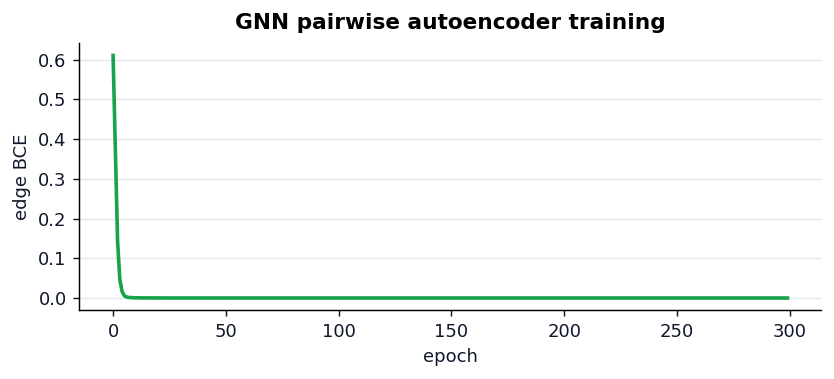

input permutation check |A_perm - P A P^T|: 0.0
GNN autoencoder permutation test:
  canonical cycle reconstruction error: 0
  permuted cycle reconstruction error:  0
  pooled latent distance canonical vs permuted: 0.000000
  decoder equivariance mean probability error: 0.000000


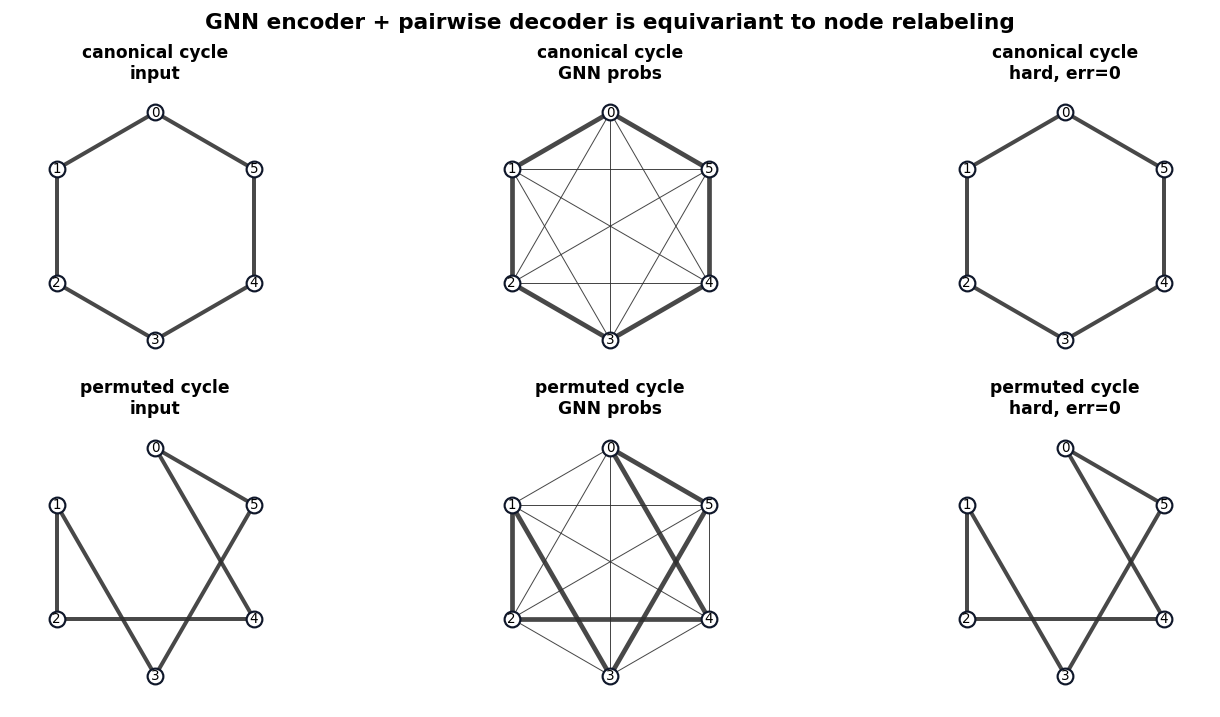

(<Figure size 1365x702 with 6 Axes>,
 array([[<Axes: title={'center': 'canonical cycle\ninput'}>,
         <Axes: title={'center': 'canonical cycle\nGNN probs'}>,
         <Axes: title={'center': 'canonical cycle\nhard, err=0'}>],
        [<Axes: title={'center': 'permuted cycle\ninput'}>,
         <Axes: title={'center': 'permuted cycle\nGNN probs'}>,
         <Axes: title={'center': 'permuted cycle\nhard, err=0'}>]],
       dtype=object))

In [73]:
class PermEquivariantGraphAutoEncoder(nn.Module):
    def __init__(self, node_dim=N_NODES + 1, hidden=64, layers=3):
        super().__init__()
        self.node_in = nn.Linear(node_dim, hidden)
        self.self_layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(layers)])
        self.neigh_layers = nn.ModuleList([nn.Linear(hidden, hidden, bias=False) for _ in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(layers)])
        self.edge_decoder = nn.Sequential(
            nn.Linear(3 * hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def encode_nodes(self, A, X):
        h = torch.relu(self.node_in(X))
        degree = A.sum(dim=-1, keepdim=True).clamp_min(1.0)
        for self_layer, neigh_layer, norm in zip(self.self_layers, self.neigh_layers, self.norms):
            msg = torch.bmm(A, neigh_layer(h)) / degree
            h = torch.relu(norm(self_layer(h) + msg))
        return h

    def decode_edges(self, h):
        pair_features = torch.cat([
            h[:, :, None, :] + h[:, None, :, :],
            torch.abs(h[:, :, None, :] - h[:, None, :, :]),
            h[:, :, None, :] * h[:, None, :, :],
        ], dim=-1)
        logits = self.edge_decoder(pair_features).squeeze(-1)
        logits = 0.5 * (logits + logits.transpose(1, 2))
        return logits

    def forward(self, A, X):
        h = self.encode_nodes(A, X)
        graph_z = h.mean(dim=1)
        edge_logits = self.decode_edges(h)
        return edge_logits, graph_z, h


def node_anchor_features(A_batch):
    """Node features that move with the nodes: one anchor channel per node plus degree."""
    B, N, _ = A_batch.shape
    eye = torch.eye(N, device=A_batch.device).unsqueeze(0).repeat(B, 1, 1)
    degree = A_batch.sum(dim=-1, keepdim=True) / max(N - 1, 1)
    return torch.cat([eye, degree], dim=-1)


def permute_graph_tensor(A, permutation):
    p = torch.tensor(permutation, dtype=torch.long, device=A.device)
    return A[:, p][:, :, p]


def permute_node_features(X, permutation):
    p = torch.tensor(permutation, dtype=torch.long, device=X.device)
    return X[:, p]


def upper_edge_bce(logits, A):
    upper = torch.triu(torch.ones(N_NODES, N_NODES, dtype=torch.bool, device=logits.device), diagonal=1)
    return F.binary_cross_entropy_with_logits(logits[:, upper], A[:, upper])


A_train = torch.tensor(np.stack([vec_to_adj(x) for x in X_graph]), dtype=torch.float32)
gnn_ae = PermEquivariantGraphAutoEncoder().to(device)
gnn_opt = torch.optim.Adam(gnn_ae.parameters(), lr=2e-3)
gnn_losses = []
rng = np.random.default_rng(7)

for epoch in range(1, 301):
    order = rng.permutation(len(A_train))
    running = 0.0
    n_seen = 0
    for start in range(0, len(order), 128):
        idx = order[start:start + 128]
        A_original = A_train[idx].to(device)
        X_original = node_anchor_features(A_original)

        # Train on a fresh random relabeling every batch. The node features move with the nodes.
        perm_batch = rng.permutation(N_NODES)
        A_batch = permute_graph_tensor(A_original, perm_batch)
        X_batch = permute_node_features(X_original, perm_batch)

        logits, _, _ = gnn_ae(A_batch, X_batch)
        loss = upper_edge_bce(logits, A_batch)
        gnn_opt.zero_grad()
        loss.backward()
        gnn_opt.step()
        running += loss.item() * len(idx)
        n_seen += len(idx)
    gnn_losses.append(running / n_seen)
    if epoch % 75 == 0:
        print(f"epoch {epoch:3d} | edge BCE {gnn_losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6.3, 2.8), constrained_layout=True)
ax.plot(gnn_losses, color=PALETTE["green"], linewidth=2)
finish_axis(ax, "GNN pairwise autoencoder training", "epoch", "edge BCE")
plt.show()

# Test the same canonical/permuted cycle that broke the fixed-order GraphVAE.
A_cycle = base_graph("cycle")
perm = np.array([2, 5, 0, 4, 1, 3])
A_cycle_perm = A_cycle[perm][:, perm]

A_cycle_t = torch.tensor(A_cycle[None, :, :], dtype=torch.float32, device=device)
A_perm_t = torch.tensor(A_cycle_perm[None, :, :], dtype=torch.float32, device=device)
X_cycle_t = node_anchor_features(A_cycle_t)
X_perm_t = permute_node_features(X_cycle_t, perm)

# This equality is the input-side equivariance relation: X and A are relabeled together.
A_perm_from_canonical = permute_graph_tensor(A_cycle_t, perm)
print("input permutation check |A_perm - P A P^T|:", torch.abs(A_perm_t - A_perm_from_canonical).sum().item())

# Decode both graphs.
gnn_ae.eval()
with torch.no_grad():
    cycle_logits, cycle_z, _ = gnn_ae(A_cycle_t, X_cycle_t)
    perm_logits, perm_z, _ = gnn_ae(A_perm_t, X_perm_t)
    cycle_probs_gnn = torch.sigmoid(cycle_logits).cpu().numpy()[0]
    perm_probs_gnn = torch.sigmoid(perm_logits).cpu().numpy()[0]
    cycle_hard_gnn = (cycle_probs_gnn >= 0.5).astype(np.float32)
    perm_hard_gnn = (perm_probs_gnn >= 0.5).astype(np.float32)

np.fill_diagonal(cycle_hard_gnn, 0.0)
np.fill_diagonal(perm_hard_gnn, 0.0)
cycle_hard_gnn = np.maximum(cycle_hard_gnn, cycle_hard_gnn.T)
perm_hard_gnn = np.maximum(perm_hard_gnn, perm_hard_gnn.T)

cycle_gnn_error = int(np.abs(adj_to_vec(A_cycle) - adj_to_vec(cycle_hard_gnn)).sum())
perm_gnn_error = int(np.abs(adj_to_vec(A_cycle_perm) - adj_to_vec(perm_hard_gnn)).sum())
latent_gnn_distance = torch.norm(cycle_z - perm_z).item()

# Output-side equivariance: decode(P A P^T, P X) should be P decode(A, X) P^T.
perm_probs_from_canonical = permute_graph_tensor(torch.tensor(cycle_probs_gnn[None, :, :], dtype=torch.float32, device=device), perm).cpu().numpy()[0]
equivariance_error = float(np.abs(perm_probs_gnn - perm_probs_from_canonical).mean())

print("GNN autoencoder permutation test:")
print(f"  canonical cycle reconstruction error: {cycle_gnn_error}")
print(f"  permuted cycle reconstruction error:  {perm_gnn_error}")
print(f"  pooled latent distance canonical vs permuted: {latent_gnn_distance:.6f}")
print(f"  decoder equivariance mean probability error: {equivariance_error:.6f}")

plot_graph_grid(
    [
        A_cycle,
        cycle_probs_gnn,
        cycle_hard_gnn,
        A_cycle_perm,
        perm_probs_gnn,
        perm_hard_gnn,
    ],
    titles=[
        "canonical cycle\ninput",
        "canonical cycle\nGNN probs",
        f"canonical cycle\nhard, err={cycle_gnn_error}",
        "permuted cycle\ninput",
        "permuted cycle\nGNN probs",
        f"permuted cycle\nhard, err={perm_gnn_error}",
    ],
    cols=3,
    node_size=0.08,
    figsize=(10.5, 5.4),
    title="GNN encoder + pairwise decoder is equivariant to node relabeling",
)


### Part 10.3 - Latent invariance under node permutation

Now we do the cleanest test: **do not perturb the latent vector at all**.

Instead, we take one cycle graph and apply several different node permutations. Each permuted adjacency matrix represents the same graph. A permutation-invariant encoder should map all of them to the same graph-level latent point.

We compare:

1. **Supervised fixed-order GraphVAE encoder:** receives a flattened edge vector, so each permutation changes the input coordinates and the supervised latent point moves.
2. **GNN encoder with pooling:** receives $(A,X)$ and uses equivariant message passing plus invariant pooling, so permuting nodes should leave the graph-level latent point unchanged.


Latent distance from the unpermuted cycle:
  perm 0: VAE distance 0.000, supervised pred cycle          | GNN pooled distance 0.000000
  perm 1: VAE distance 5.123, supervised pred cycle          | GNN pooled distance 0.000000
  perm 2: VAE distance 4.606, supervised pred star           | GNN pooled distance 0.000000
  perm 3: VAE distance 4.904, supervised pred star           | GNN pooled distance 0.000000
  perm 4: VAE distance 4.200, supervised pred path           | GNN pooled distance 0.000000
  perm 5: VAE distance 4.568, supervised pred two_triangles  | GNN pooled distance 0.000000

Average distance over non-identity permutations:
  supervised fixed-order VAE: 4.680
  GNN + pooling:   0.000000


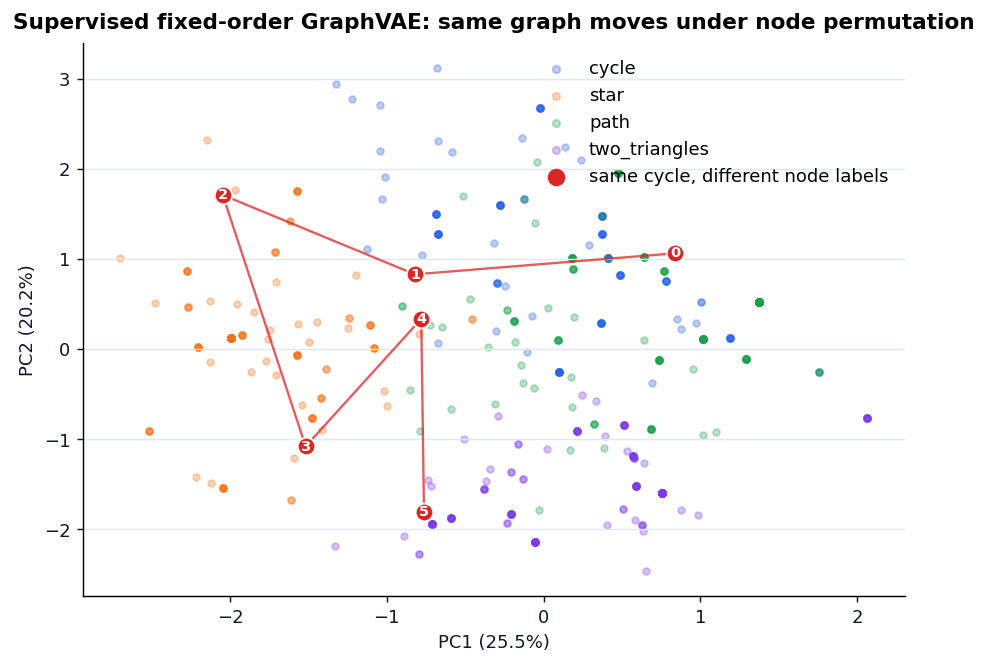

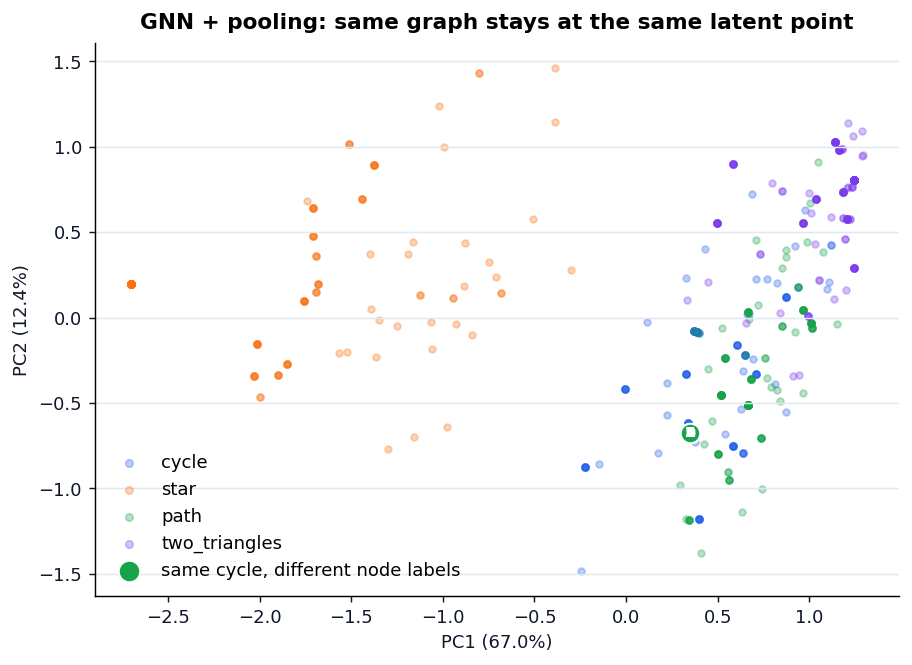

In [74]:
def permute_numpy_graph(A, permutation):
    return A[np.ix_(permutation, permutation)]


def encode_vae_mu_for_adjacencies(adjacencies):
    X_perm = torch.tensor(np.stack([adj_to_vec(A) for A in adjacencies]), dtype=torch.float32, device=device)
    vae.eval()
    with torch.no_grad():
        mu, _ = vae.encode(X_perm)
        labels = vae.latent_class_logits(mu).argmax(dim=1).cpu().numpy()
    return mu.cpu().numpy(), labels


def encode_gnn_graph_z_for_adjacencies(adjacencies, permutations_from_base):
    gnn_ae.eval()
    zs = []
    A_base_t = torch.tensor(adjacencies[0][None, :, :], dtype=torch.float32, device=device)
    X_base_t = node_anchor_features(A_base_t)
    with torch.no_grad():
        for A_np, p in zip(adjacencies, permutations_from_base):
            A_t = torch.tensor(A_np[None, :, :], dtype=torch.float32, device=device)
            X_t = permute_node_features(X_base_t, p)
            _, graph_z, _ = gnn_ae(A_t, X_t)
            zs.append(graph_z.cpu().numpy()[0])
    return np.stack(zs)


# One graph, many node relabelings.
A_cycle = base_graph("cycle")
permutation_list = make_nontrivial_cycle_permutations(A_cycle, n_permutations=6)
cycle_permuted_graphs = [permute_numpy_graph(A_cycle, p) for p in permutation_list]

# Supervised fixed-order GraphVAE latents for each relabeling.
vae_perm_mu, vae_perm_labels = encode_vae_mu_for_adjacencies(cycle_permuted_graphs)
vae_pairwise_dist = np.linalg.norm(vae_perm_mu - vae_perm_mu[:1], axis=1)

# GNN pooled graph latents for each relabeling.
gnn_perm_z = encode_gnn_graph_z_for_adjacencies(cycle_permuted_graphs, permutation_list)
gnn_pairwise_dist = np.linalg.norm(gnn_perm_z - gnn_perm_z[:1], axis=1)

print("Latent distance from the unpermuted cycle:")
for idx, p in enumerate(permutation_list):
    print(
        f"  perm {idx}: VAE distance {vae_pairwise_dist[idx]:.3f}, "
        f"supervised pred {kinds[vae_perm_labels[idx]]:14s} | "
        f"GNN pooled distance {gnn_pairwise_dist[idx]:.6f}"
    )

print()
print("Average distance over non-identity permutations:")
print(f"  supervised fixed-order VAE: {vae_pairwise_dist[1:].mean():.3f}")
print(f"  GNN + pooling:   {gnn_pairwise_dist[1:].mean():.6f}")

# -----------------------------------------------------------------------------
# Visualization 1: VAE latent space. Same graph under permutations moves around.
# -----------------------------------------------------------------------------
vae.eval()
with torch.no_grad():
    mu_all, _ = vae.encode(X_tensor.to(device))
vae_latent = mu_all.cpu().numpy()
vae_mean = vae_latent.mean(axis=0, keepdims=True)
vae_centered = vae_latent - vae_mean
_, vae_singular_values, vae_vh = np.linalg.svd(vae_centered, full_matrices=False)
vae_latent_2d = vae_centered @ vae_vh[:2].T
vae_perm_2d = (vae_perm_mu - vae_mean) @ vae_vh[:2].T
vae_explained = vae_singular_values**2 / (len(vae_centered) - 1)
vae_explained_ratio = vae_explained / vae_explained.sum()

fig, ax = plt.subplots(figsize=(6.9, 5.0), constrained_layout=True)
colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["green"], PALETTE["purple"]]
for label, kind in enumerate(kinds):
    mask = y_graph == label
    ax.scatter(vae_latent_2d[mask, 0], vae_latent_2d[mask, 1], s=14, alpha=0.30, color=colors[label], label=kind)

ax.plot(vae_perm_2d[:, 0], vae_perm_2d[:, 1], color="#dc2626", linewidth=1.3, alpha=0.75)
ax.scatter(vae_perm_2d[:, 0], vae_perm_2d[:, 1], s=95, color="#dc2626", edgecolors="white", linewidths=1.0, zorder=5, label="same cycle, different node labels")
for idx, xy in enumerate(vae_perm_2d):
    ax.text(xy[0], xy[1], str(idx), fontsize=8, ha="center", va="center", color="white", fontweight="bold", zorder=6)
finish_axis(
    ax,
    "Supervised fixed-order GraphVAE: same graph moves under node permutation",
    f"PC1 ({vae_explained_ratio[0]:.1%})",
    f"PC2 ({vae_explained_ratio[1]:.1%})",
    grid=True,
)
ax.legend(markerscale=1.1, loc="best")
plt.show()

# -----------------------------------------------------------------------------
# Visualization 2: GNN pooled latent space. Same graph stays in the same place.
# -----------------------------------------------------------------------------
gnn_ae.eval()
gnn_background = []
with torch.no_grad():
    for start in range(0, len(A_train), 128):
        A_batch = A_train[start:start + 128].to(device)
        X_batch = node_anchor_features(A_batch)
        _, graph_z, _ = gnn_ae(A_batch, X_batch)
        gnn_background.append(graph_z.cpu().numpy())
gnn_background = np.concatenate(gnn_background, axis=0)

gnn_mean = gnn_background.mean(axis=0, keepdims=True)
gnn_centered = gnn_background - gnn_mean
_, gnn_singular_values, gnn_vh = np.linalg.svd(gnn_centered, full_matrices=False)
gnn_background_2d = gnn_centered @ gnn_vh[:2].T
gnn_perm_2d = (gnn_perm_z - gnn_mean) @ gnn_vh[:2].T
gnn_explained = gnn_singular_values**2 / (len(gnn_centered) - 1)
gnn_explained_ratio = gnn_explained / gnn_explained.sum()

fig, ax = plt.subplots(figsize=(6.9, 5.0), constrained_layout=True)
for label, kind in enumerate(kinds):
    mask = y_graph == label
    ax.scatter(gnn_background_2d[mask, 0], gnn_background_2d[mask, 1], s=14, alpha=0.30, color=colors[label], label=kind)

ax.scatter(gnn_perm_2d[:, 0], gnn_perm_2d[:, 1], s=115, color="#16a34a", edgecolors="white", linewidths=1.0, zorder=5, label="same cycle, different node labels")
for idx, xy in enumerate(gnn_perm_2d):
    ax.text(xy[0], xy[1], str(idx), fontsize=8, ha="center", va="center", color="white", fontweight="bold", zorder=6)
finish_axis(
    ax,
    "GNN + pooling: same graph stays at the same latent point",
    f"PC1 ({gnn_explained_ratio[0]:.1%})",
    f"PC2 ({gnn_explained_ratio[1]:.1%})",
    grid=True,
)
ax.legend(markerscale=1.1, loc="best")
plt.show()
